In [1]:
  import importlib                                                                                                                                                                                                                          
  import helpers                                                                                                                                                                                                                            
  importlib.reload(helpers)  

<module 'helpers' from '/Users/flinder/mc_measurement/helpers.py'>

In [2]:
!conda info --envs


# conda environments:
#
# * -> active
# + -> frozen
base                     /Users/flinder/miniconda3
mc_scale                 /Users/flinder/miniconda3/envs/mc_scale
mcgrad_tutorials     *   /Users/flinder/miniconda3/envs/mcgrad_tutorials
test                     /Users/flinder/miniconda3/envs/test
test_repro               /Users/flinder/miniconda3/envs/test_repro
test_skversion           /Users/flinder/miniconda3/envs/test_skversion



In [3]:
# Install latest MCGrad version

In [4]:
!pip install -q "MCGrad[tutorials] @ git+https://github.com/facebookincubator/MCGrad.git"

In [5]:
import numpy as np
import pandas as pd
from sklearn import metrics as skmetrics
from sklearn.model_selection import train_test_split

from mcgrad import metrics, methods, plotting

* To keep this tutorial compact, helper functions are located in `helpers.py` in this directory.

In [6]:
from helpers import (
    BINARY_COLUMNS,
    CATEGORICAL_COLUMNS,
    LABEL_COLUMN,
    NUMERICAL_COLUMNS,
    combine_segment_calibration_plots,
    configure_logging,
    create_logistic_pipeline,
    format_calibration_metrics_table,
    load_acs_employment_data,
    setup_plotting,
    # Prevalence estimation helpers
    compute_rogan_gladen_estimate,
    estimate_classifier_error_rates,
    compute_prevalence_estimates,
    compute_prevalence_bias,
    # Threshold calibration
    calibrate_threshold_prevalence_matching,
    calibrate_threshold_optimal_accuracy,
)

In [7]:
# Notebook setup
setup_plotting()
configure_logging()

### 1.1 Dataset and ML task

We use a sample of the American Community Survey (ACS) dataset containing information on respondents' *employment status* (binary: employed/unemployed) along with sociodemographic features:

| Column Name | Description |
|-------------|-------------|
| AGEP | Age of the individual (in years) |
| SCHL | Educational attainment (ordinal code for highest level of schooling) |
| MAR | Marital status |
| RELP | Relationship to the household reference person |
| DIS | Disability status indicator |
| ESP | English-speaking ability (limited English proficiency indicator) |
| CIT | Citizenship status |
| MIG | Mobility status (whether the person lived in the same house 1 year ago) |
| MIL | Military service status |
| ANC | Ancestry (self-reported primary ancestry) |
| NATIVITY | Nativity (U.S.-born vs foreign-born) |
| DEAR | Hearing difficulty indicator |
| DEYE | Vision difficulty indicator |
| DREM | Cognitive difficulty indicator |
| SEX | Sex |
| RAC1P | Race (single-race category) |
| **employment_label** | Employment status (binary target variable) |

In [8]:
employment_df = load_acs_employment_data(states=["TX", "MI", "PA"])
employment_df.head()

Dataset has 496585 samples


,AGEP,SCHL,MAR,RELP,DIS,ESP,CIT,MIG,MIL,ANC,NATIVITY,DEAR,DEYE,DREM,SEX,RAC1P,employment_label
0,21.0,16.0,5,17,2,0,1,1,4,1,1,2,2,2,2,2,True
1,19.0,16.0,5,17,2,0,1,1,4,1,1,2,2,2,2,1,False
2,24.0,12.0,5,16,1,0,1,1,4,1,1,2,2,1,1,2,False
3,20.0,16.0,5,17,2,0,1,1,3,1,1,2,2,2,2,1,True
4,31.0,17.0,5,17,2,0,1,3,4,4,1,2,2,2,1,1,True


Instructions:

Take this draft writeup as context:

[Start of writeup]
The Crucial Role of Multicalibration in Model-based Prevalence Measurement

Measuring the prevalence of a category within a target population is a task common across many scientific applications. This method includes use of diagnostic tests to measure disease prevalence, measuring prevalence of phenomena on online platforms, and identifying the frequency with which documents in a corpus address a specific topic. Prevalence estimation - or “quantification” in computer science terminology - typically involves using an imperfect measurement device to classify examples into categories. Devices might include crowdsourced human annotators, calibrated predicted probability models, traditional threshold-based machine learning classifiers, or large language models (LLMs). Notably the availability of LLMs has made zero-shot quantification of arbitrary phenomena in even very large corpuses easy and affordable.

While quantification is a well-studied problem (Gonzalez et al.), and several methods exist to adjust for imperfect devices <CITATION>, we demonstrate that all of these devices can fail to recover correct prevalence estimates even in common settings. Nearly all existing methods attempt to learn or calibrate the imperfect device by learning the device’s error properties on a training population of examples and apply that calibrated device to the target population(s). 

We introduce the property of multicalibration to demonstrate that only multicalibrated classifiers can accurately perform this out-of-domain prevalence estimation. This includes nearly all practical applications of quantification: applying a quantification model to a previously unseen dataset, applying a quantification model to a repeatedly sampled population over time to track changes in prevalence, and even applying a quantification to subsets of its own training population. Simple calibration is necessary but insufficient for unbiased estimation of prevalence, except in trivial and unrealistic settings.

We review existing approaches to the quantification problem, introduce calibration and multicalibration, demonstrate the need for multicalibration to achieve unbiased estimates of prevalence in out-of-domain settings, and apply those insights to a few real-world datasets.
Theory - (Multi-) Calibration for Measurement
Assume a binary problem with outcome y in {0, 1} and a set of relevant features X. The researcher relies on an imperfect device, h(X), such as a diagnostic test, a human annotator, or a machine learning classifier (including LLMs). The task of "quantification" is to estimate the true prevalence, P(y=1), in a target population using only the device’s outputs.

Existing Calibration Approaches
The most intuitive approach, "Classify & Count," simply tallies the device's positive predictions. However, this method is fundamentally flawed; even highly accurate devices yield biased estimates whenever the false positive and false negative rates are non-zero and uncorrected. To address this, the quantification literature has historically relied on error correction methods, such as the "Adjusted Count" (AC) (In epidemiology, this correction is widely known as the Rogan-Gladen estimator). These methods use a classifier's fixed error rates (tpr and fpr) estimated from training data to invert the confusion matrix and recover the true prevalence (Gonzales et al. 2017)

[footnote (?) about other non-classification methods (King; Resnick; etc.)]

Adjusted Count is a calibration technique. If a device is perfectly calibrated (i.e., its predicted probabilities match empirical frequencies), averaging its predictions yields an unbiased prevalence estimate. Reformulating Adjusted Count, we can treat the device’s classifications as real numbers rather than discrete predicted values {0,1}, which correspond to the prevalence within each predicted class. Positively classified examples are scored by the tpr and negatively classified examples are scored by 1-fpr. These scores satisfy the definition of calibration that E[y | y_hat] = y. The Adjusted Count (Rogan-Gladen) estimate is equivalent to the mean of these scores.

A prediction y_hat is perfectly calibrated if and only if P(y = 1 | y_hat = 𝑝) = 𝑝, where 𝑝 is the true underlying probability. Intuitively, for all y = 0.8, we expect that 80% of them have 1 as a label.

[note that: Recent review (Grimmer, Roberts, Stewart) hardly mention calibration at all]

Corrections such as AC rely on a strict and often unrealistic assumption: they assume that while the class prevalence P(y) may change, the distribution of features within each class, P(X|y), remains constant between the training and target populations. This assumption of "Feature Stability" fails in most real-world out-of-distribution (OOD) settings. For example, if a device is applied to a specific demographic subgroup or a future time period, the features characterizing the positive class often shift, altering the device's error rates  and rendering the standard correction invalid. (Wu / Resnik 2024)
This can be demonstrated for AC. Consider a population consisting of two groups, indexed by i, of sizes {k, 1-k}. Each group is defined by a prevalence, p_i, and error rates fpr_i and fnr_i. The apparent overall fpr and fnr of population is a weighted average of the error rates for the two groups. In the presence of a “mix shift” that changes the relative sizes of these groups {k*, 1-k*}, the learned tpr and tnr will no longer be an appropriately weighted average of the target population group-level error rates, {tpr*, tnr*}. Estimated prevalence - corrected by an inappropriate global confusion matrix - will be biased. Despite achieving “calibration” in the original population, this learned calibration does not always hold.

[something about why we should care about bias (versus variance)]

While theoretically sound, reliance on global calibration introduces a subtle but critical failure mode. A device can be globally calibrated on a training set - accurate on average - while being grossly miscalibrated on specific subgroups, even within the training distribution. When researchers apply such a model to a new domain - whether a specific demographic subset, a new geographic region, or a future time period - the global calibration curve often fails to hold.
This failure occurs because most real-world distribution shifts are effectively changes in the composition of the population. If the device is miscalibrated on the underlying subgroups that make up the population, any shift in their proportions will bias the aggregate estimate. This phenomenon, which we term mis-multicalibration, violates the Calibration Stability assumption locally and negatively impacts generalization.
Consequently, neither standard error-correction methods (which assume stable features) nor standard calibration methods (which assume stable global calibration) can yield unbiased estimates under shift. 
To illustrate our theoretical results, we use a simulation with the following structure. We generate synthetic data with a binary covariate $X \in {0, 1}$ and binary outcome $Y \in {0, 1}$, where $P(Y=1|X=1) = 0.85$ and $P(Y=1|X=0) = 0.15$. A classifier produces probability estimates $\hat{p}$ that are systematically miscalibrated: underestimating by 10% when $X=0$ and overestimating by 10% when $X=1$. All calibration parameters are learned on a training distribution with $P(X=0) = 0.5$. We then evaluate estimation methods on test distributions where $P(X=0)$ ranges from 0.01 to 0.99, representing covariate shift. The marginal distribution $P(X)$ changes while the conditional $P(Y|X)$ remains fixed. The simulation is repeated 50 times. 


a)

b)

c)

d)

Figure 1: Bias of the global prevalence estimate under covariate shift and three adjustment methods. a) no adjustment, averaging raw model predictions, b) averaging binarized model predictions from a (globally) calibrated threshold, c) averaging predictions calibrated on a calibration sample, d) Adjusted Count (Rogan-Gladen adjustment) with TPR and FPR estimated from a calibration sample.


Figure 1 displays the results for (a) the raw simulated model prediction, (b) a classify-and-count procedure with a calibrated threshold, c) probability calibrated model scores, and (d) the adjusted-count method (Rogan-Gladen). The y-axis shows the bias in global prevalence estimates under varying covariate shift, which is displayed on the x-axis. It can be seen that with zero distribution shift—the center of the figures—the raw score average is biased by about 7%. The classify-and-count, calibration, and the Rogan-Gladen estimators show no bias when there is no distribution shift, but their prevalence estimates are biased if the distribution shifts. The threshold based estimators (CC, and RG) are much more prone to extreme bias—in this sample up to 250%—as the covariate shift becomes more extreme. The calibrated scores are less susceptible to such bias amplification.

Multicalibration
To guarantee accurate quantification in out-of-domain settings, a device must satisfy multicalibration: it must be calibrated not just on average, but simultaneously across all practically relevant subpopulations. By ensuring the device is reliable on these "atomic" components, multicalibration provides robustness not just for subsetting, but for generalizing to any future distribution composed of these groups. (Gopalan et al., 2022)
Multicalibration was initially introduced as a fairness criterion (e.g., Hébert-Johnson et al., 2018; Błasiok et al., 2023/2024) and a growing body of research showed its relevance to several aspects of model performance and robustness ([14, 16, 22, 34, 59, 60] from KDD paper). Formally, let (X) denote features, (Y \in {0,1}) an outcome, and (f(X) \in [0,1]) a predictor interpreted as a probability. Given a collection (\mathcal{G}) of subgroups (G \subseteq \mathcal{X}) (for example, groups defined by demographic attributes or by arbitrary computable functions of (X)), (f) is said to be (\alpha)-multicalibrated with respect to (\mathcal{G}) if, for every group (G \in \mathcal{G}) and every prediction value (v) used by the model, the conditional expectation satisfies
[
\left| \mathbb{E}[Y \mid f(X)=v,, X \in G] - v \right| \le \alpha,
]
whenever the conditioning event has sufficient probability mass. In words, within each subgroup and at each score level, the average observed outcome closely matches the predicted probability. This notion strengthens classical calibration, which requires the condition only over the entire population, by enforcing reliability across a rich family of subpopulations, potentially exponential in size. 

[Fill how this applies to measurement and illustrate with simulation]

===[End of Writeup]===



This notebook loads the ACS dataset with a couple of features and a binary employment label. We want to use this data to demonstrate what we are arguing theoretically in the draft and showing in the simulation. 

First step: Let's brainstorm what analysis makes sense to show. Some initial ideas: 
1) a) take a sample of the whole dataset. b) Train a classifier for employment status, c) use the classifier to estimate prevalence in a held out (but in-distribution) dataset, using different adjustments: Raw scores, RG, probability calibration (isotonic regression), multicalibration (MCGrad) - measure bias
2) Change step c) from 1): Instead of estimating prevalence on a subset of the same distribution, estimate prevalence for sub-segments of the held out set (e.g. states) - simulating a comparison of prevalences - and measure bias
3) Train the model and calibration on a subset of the distribution (say a number of states) and apply it for prevalence estimation out of  distribution (say held out states)



Second step: Implement analyses
- for this implementation check out the notebook ./mcgrad_tutorial_notebook.ipynb. Ideally use the methods employed there for calibration / multicalibration. Also the logistic pipeline (see helpers.py) would probably be a good base model

## 2. Data Loading and Model Training

We load ACS data from multiple states. We'll use a subset for training/calibration and hold out others for OOD evaluation.

In [9]:
# Load data from multiple states and years for more robust analysis
# Training states: Large, geographically diverse states
# OOD states: Held out for out-of-distribution evaluation

TRAIN_STATES = ["TX", "MI", "PA", "OH", "IL", "GA", "NC", "VA"]
OOD_STATES = ["CA", "NY", "FL", "WA", "AZ", "CO"]

# Use multiple survey years for more data
SURVEY_YEARS = ["2016", "2017", "2018"]

print(f"Loading training data: {len(TRAIN_STATES)} states x {len(SURVEY_YEARS)} years...")
train_source_df = load_acs_employment_data(
    states=TRAIN_STATES, 
    survey_years=SURVEY_YEARS,
    include_state=True,
    include_year=True,
)
print(f"Training states: {len(train_source_df)} total samples")
print(f"  By state: {train_source_df['STATE'].value_counts().to_dict()}")
print(f"  By year: {train_source_df['YEAR'].value_counts().to_dict()}")

print(f"\nLoading OOD data: {len(OOD_STATES)} states x {len(SURVEY_YEARS)} years...")
ood_df = load_acs_employment_data(
    states=OOD_STATES, 
    survey_years=SURVEY_YEARS,
    include_state=True,
    include_year=True,
)
print(f"OOD states: {len(ood_df)} total samples")
print(f"  By state: {ood_df['STATE'].value_counts().to_dict()}")

Loading training data: 8 states x 3 years...
Dataset has 3066049 samples
Training states: 3066049 total samples
  By state: {'TX': 795838, 'PA': 383769, 'IL': 379272, 'OH': 355354, 'NC': 303352, 'GA': 298718, 'MI': 297023, 'VA': 252723}
  By year: {2018: 1030260, 2017: 1023512, 2016: 1012277}

Loading OOD data: 6 states x 3 years...
Dataset has 2917368 samples
OOD states: 2917368 total samples
  By state: {'CA': 1132427, 'FL': 598632, 'NY': 589656, 'WA': 223303, 'AZ': 207251, 'CO': 166099}


In [10]:
# Split training data into train/calibration and held-out test sets
from sklearn.model_selection import train_test_split

# Stratify by both label and state to ensure balanced representation
train_df, test_df = train_test_split(
    train_source_df, 
    test_size=0.30, 
    random_state=42, 
    stratify=train_source_df[[LABEL_COLUMN, "STATE"]].apply(tuple, axis=1)
)

# Further split train into model training and calibration sets
model_train_df, calibration_df = train_test_split(
    train_df, 
    test_size=0.30, 
    random_state=42, 
    stratify=train_df[[LABEL_COLUMN, "STATE"]].apply(tuple, axis=1)
)

print(f"Model training set: {len(model_train_df):,} samples")
print(f"Calibration set: {len(calibration_df):,} samples")
print(f"In-distribution test set: {len(test_df):,} samples")
print(f"\nState distribution in test set:")
print(test_df["STATE"].value_counts().to_dict())

Model training set: 1,502,363 samples
Calibration set: 643,871 samples
In-distribution test set: 919,815 samples

State distribution in test set:
{'TX': 238752, 'PA': 115131, 'IL': 113781, 'OH': 106607, 'NC': 91005, 'GA': 89616, 'MI': 89106, 'VA': 75817}


In [11]:
# Train the base logistic regression model
# Exclude STATE and YEAR from features (they're for segmentation analysis, not prediction)
feature_cols = [c for c in model_train_df.columns if c not in [LABEL_COLUMN, "STATE", "YEAR"]]

X_train = model_train_df[feature_cols]
y_train = model_train_df[LABEL_COLUMN].astype(int).to_numpy()

logistic_pipeline = create_logistic_pipeline()
logistic_pipeline.fit(X_train, y_train)
print(f"Base model trained on {len(feature_cols)} features")

Base model trained on 16 features


In [12]:
# Generate base model predictions for all datasets
BASE_MODEL_COL = 'base_model_prediction'

for df in [calibration_df, test_df, ood_df]:
    # Use only the feature columns (exclude STATE, YEAR, and label)
    X = df[[c for c in df.columns if c not in [LABEL_COLUMN, "STATE", "YEAR"]]]
    df[BASE_MODEL_COL] = logistic_pipeline.predict_proba(X)[:, 1]

print("Base model predictions generated for all datasets")

Base model predictions generated for all datasets


In [13]:
# Fit calibration methods on the calibration set

# 1. Isotonic Regression (global calibration)
isotonic_regression = methods.IsotonicRegression().fit(
    calibration_df,
    BASE_MODEL_COL,
    LABEL_COLUMN,
)
print("Isotonic regression fitted")

# 2. MCGrad (multicalibration)
categorical_segment_features = CATEGORICAL_COLUMNS + BINARY_COLUMNS
numerical_segment_features = NUMERICAL_COLUMNS

mcgrad = methods.MCGrad()
mcgrad = mcgrad.fit(
    calibration_df,
    BASE_MODEL_COL,
    LABEL_COLUMN,
    categorical_feature_column_names=categorical_segment_features,
    numerical_feature_column_names=numerical_segment_features,
)
print("MCGrad fitted")

[WARNING][2026-02-20 16:01:38][methods.py:1464]: Found 6532 (1.01%) predictions with extreme values (boundaries: [4.53979e-05, 0.999955]). These samples will be clipped in the unshrink step. Consider reviewing input prediction quality.
[INFO][2026-02-20 16:01:38][methods.py:550]: Preprocessing input data with 643871 rows; in_fit_phase = True


Isotonic regression fitted


[INFO][2026-02-20 16:01:38][methods.py:649]: Early stopping activated, max_num_rounds=100 (timeout: 28800s)
[INFO][2026-02-20 16:01:38][methods.py:959]: Determining optimal number of rounds
[INFO][2026-02-20 16:01:38][methods.py:1283]: Found a relatively small effective sample size (643,871.0), choosing k-fold for early stopping. You can override this by explicitly setting `early_stopping_use_crossvalidation` to `False`.
[INFO][2026-02-20 16:01:38][methods.py:929]: Running early stopping using Cross Validation.
[INFO][2026-02-20 16:01:38][methods.py:949]: Using 5 folds for cross-validation.
[INFO][2026-02-20 16:01:38][methods.py:986]: Evaluating round 0 (input prediction for early stopping baseline)
[INFO][2026-02-20 16:01:39][methods.py:1118]: Round 0: validation loss = 0.4177 (best: 0.4177, patience: 0/0)
[INFO][2026-02-20 16:01:39][methods.py:986]: Evaluating round 1
[INFO][2026-02-20 16:01:41][methods.py:1118]: Round 1: validation loss = 0.3853 (best: 0.3853, patience: 0/0)
[INFO][

MCGrad fitted


In [14]:
# Generate calibrated predictions for all evaluation datasets
IR_COL = 'isotonic_prediction'
MCGRAD_COL = 'mcgrad_prediction'

for df in [test_df, ood_df]:
    # Isotonic regression predictions
    df[IR_COL] = isotonic_regression.predict(df, BASE_MODEL_COL)
    
    # MCGrad predictions
    df[MCGRAD_COL] = mcgrad.predict(
        df=df,
        prediction_column_name=BASE_MODEL_COL,
        categorical_feature_column_names=categorical_segment_features,
        numerical_feature_column_names=numerical_segment_features,
    )

print("Calibrated predictions generated")

[INFO][2026-02-20 16:05:35][methods.py:550]: Preprocessing input data with 919815 rows; in_fit_phase = False
[INFO][2026-02-20 16:05:42][methods.py:550]: Preprocessing input data with 2917368 rows; in_fit_phase = False


Calibrated predictions generated


In [15]:
# Calibrate threshold and estimate TPR/FPR from calibration set

# Use prevalence-matching threshold: ensures Classify & Count is unbiased on calibration distribution
THRESHOLD = calibrate_threshold_prevalence_matching(
    labels=calibration_df[LABEL_COLUMN],
    predictions=calibration_df[BASE_MODEL_COL],
)
print(f"Calibrated threshold (prevalence-matching): {THRESHOLD:.4f}")
print(f"  (vs naive 0.5 threshold)")

# Estimate TPR and FPR at calibrated threshold for Rogan-Gladen
calibration_tpr, calibration_fpr = estimate_classifier_error_rates(
    labels=calibration_df[LABEL_COLUMN],
    predictions=calibration_df[BASE_MODEL_COL],
    threshold=THRESHOLD,
)

print(f"\nCalibration set error rates at threshold={THRESHOLD:.4f}:")
print(f"  TPR (sensitivity): {calibration_tpr:.4f}")
print(f"  FPR (1-specificity): {calibration_fpr:.4f}")

# Verify: at this threshold, apparent prevalence should match true prevalence
apparent_prev = (calibration_df[BASE_MODEL_COL] >= THRESHOLD).mean()
true_prev = calibration_df[LABEL_COLUMN].mean()
print(f"\nVerification:")
print(f"  True prevalence in calibration set: {true_prev:.4f}")
print(f"  Apparent prevalence at calibrated threshold: {apparent_prev:.4f}")

Calibrated threshold (prevalence-matching): 0.5667
  (vs naive 0.5 threshold)

Calibration set error rates at threshold=0.5667:
  TPR (sensitivity): 0.7821
  FPR (1-specificity): 0.1811

Verification:
  True prevalence in calibration set: 0.4539
  Apparent prevalence at calibrated threshold: 0.4539


### 2.1 Model Evaluation: Calibration and Multicalibration Metrics

Evaluate discriminative performance (log-loss, ROCAUC) and calibration quality (ECCE, MCE) for all methods.

In [16]:
# Compute calibration and performance metrics for all methods
from sklearn import metrics as skmetrics

def compute_ecce_with_sigma(labels, predictions):
    """Compute ECCE and its sigma scale."""
    return metrics.ecce(labels, predictions), metrics.ecce_sigma(labels, predictions)

# Define score columns to evaluate
score_columns = {
    "Base Model": BASE_MODEL_COL,
    "Isotonic Regression": IR_COL,
    "MCGrad": MCGRAD_COL,
}

# Compute MulticalibrationError objects for each method
mce_objects = {}
for method_name, score_col in score_columns.items():
    print(f"Computing MCE for {method_name}...")
    mce_objects[method_name] = metrics.MulticalibrationError(
        df=test_df,
        label_column=LABEL_COLUMN,
        score_column=score_col,
        categorical_segment_columns=CATEGORICAL_COLUMNS + BINARY_COLUMNS,
        numerical_segment_columns=NUMERICAL_COLUMNS,
    )

print("Done computing MCE objects")

Computing MCE for Base Model...
Computing MCE for Isotonic Regression...
Computing MCE for MCGrad...
Done computing MCE objects


In [22]:
# Compute performance and calibration metrics
evaluation_metrics = {
    "ROCAUC": skmetrics.roc_auc_score,
    "log_loss": skmetrics.log_loss,
}

perf_metrics = {}
calibration_metrics = {}

for method_name, score_col in score_columns.items():
    mce_obj = mce_objects[method_name]
    
    # Performance metrics
    perf_metrics[method_name] = {
        metric_name: metric_func(
            test_df[LABEL_COLUMN].values,
            test_df[score_col].values,
        )
        for metric_name, metric_func in evaluation_metrics.items()
    }
    
    # Calibration metrics
    calibration_metrics[method_name] = {
        "ECCE": mce_obj.global_ecce / 100 * mce_obj._prevalence,
        "ECCE σ": mce_obj.global_ecce_sigma,
        "MCE": mce_obj.mce,
        "MCE σ": mce_obj.mce_sigma,
    }

# Display performance metrics
print("=== Discriminative Performance ===")
display(pd.DataFrame(perf_metrics).T.round(4))

# Display calibration metrics
print("\n=== Calibration & Multicalibration ===")
display(format_calibration_metrics_table(calibration_metrics).round(4))

=== Discriminative Performance ===


,ROCAUC,log_loss
Base Model,0.8820,0.4179
Isotonic Regression,0.8822,0.4161
MCGrad,0.9117,0.3651



=== Calibration & Multicalibration ===


Calibration          Multicalibration         
                           ECCE   ECCE σ              MCE    MCE σ
Base Model                  0.0  21.9671           0.0346  89.2241
Isotonic Regression         0.0   1.5257           0.0351  91.3055
MCGrad                      0.0   1.7348           0.0022   6.1580

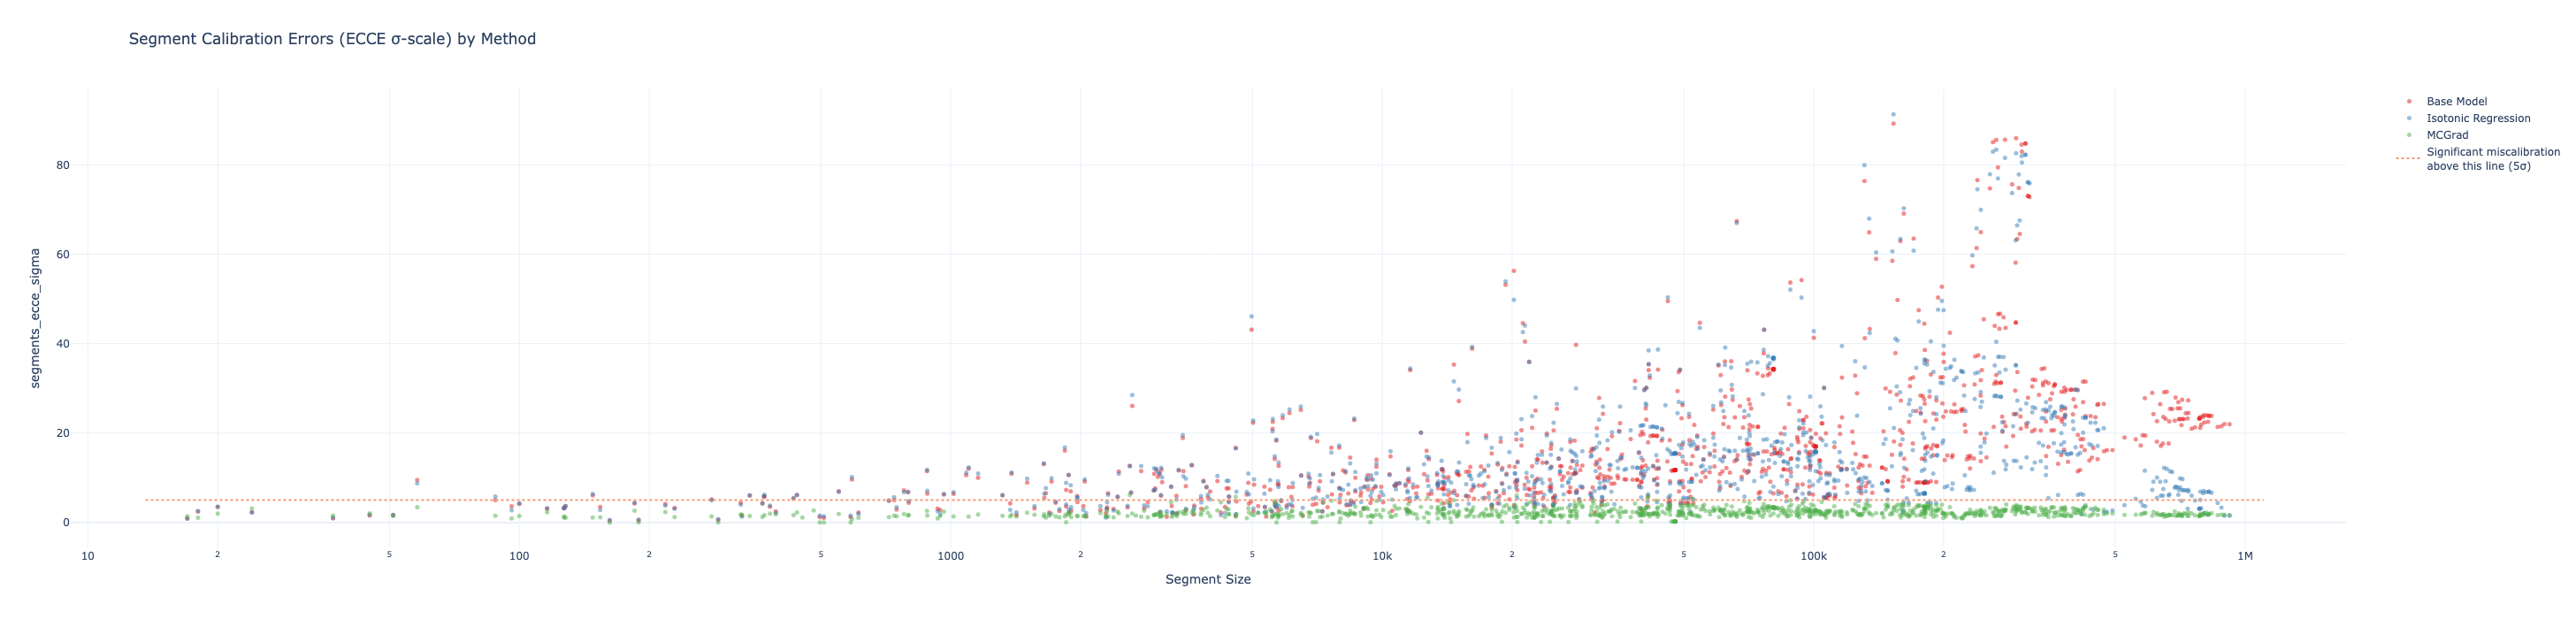

In [27]:
# Visualize segment-level calibration errors across methods
segment_ecce_plots = {}

for method_name in score_columns.keys():
    segment_ecce_plots[method_name] = plotting.plot_segment_calibration_errors(
        mce=mce_objects[method_name],
        quantity="segments_ecce_sigma",
    ).update_layout(width=700)

combine_segment_calibration_plots(
    segment_plots=segment_ecce_plots,
    quantity="segments_ecce_sigma",
).update_layout(
    height=700, 
    width=1000,
    title="Segment Calibration Errors (ECCE σ-scale) by Method",
)

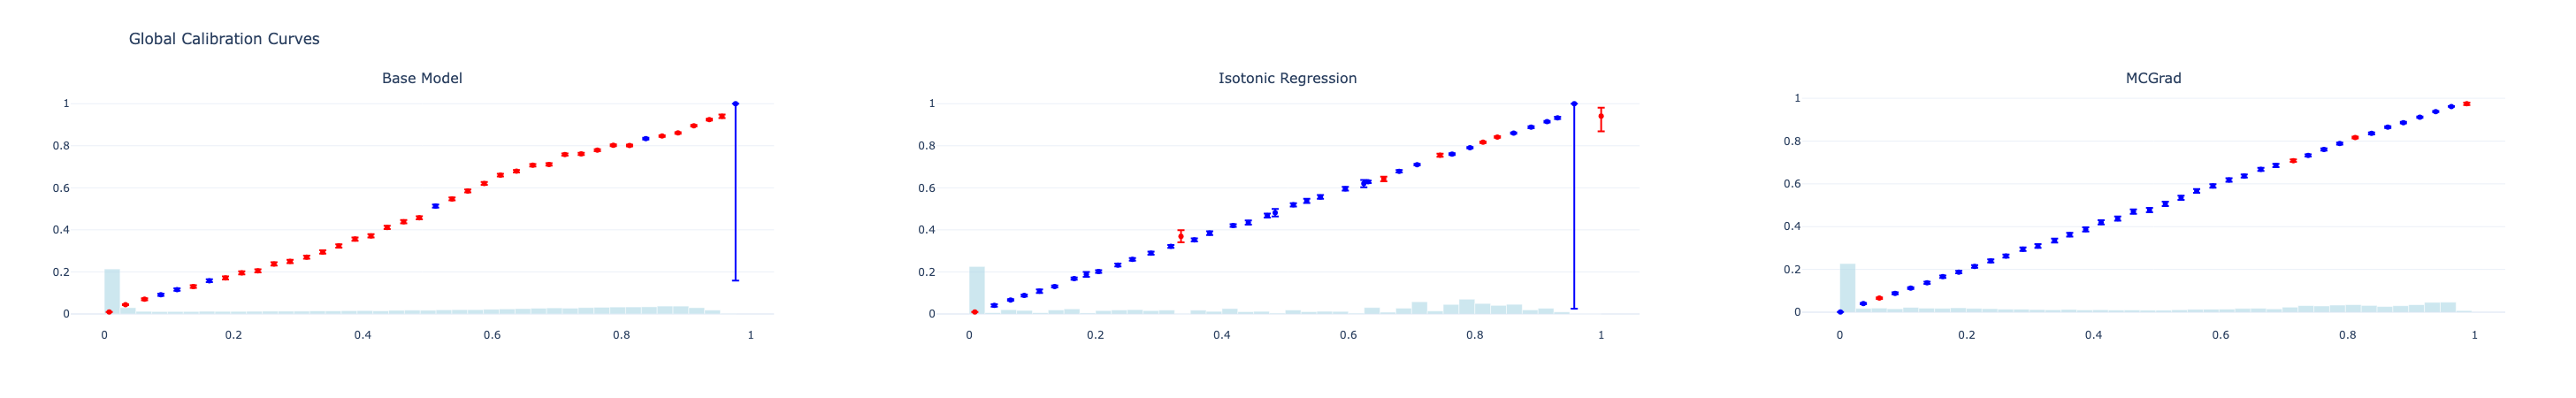

In [28]:
# Plot global calibration curves for each method
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=list(score_columns.keys()),
)

for i, (method_name, score_col) in enumerate(score_columns.items(), start=1):
    cal_fig = plotting.plot_global_calibration_curve(
        data=test_df,
        score_col=score_col,
        label_col=LABEL_COLUMN,
        num_bins=40,
    )
    
    # Add traces from the calibration figure
    for trace in cal_fig.data:
        trace.showlegend = False
        fig.add_trace(trace, row=1, col=i)

fig.update_layout(
    title="Global Calibration Curves",
    height=450,
    width=1200,
)
fig.show()

## 3. Analysis 1: In-Distribution Baseline

First, we verify that all methods yield approximately unbiased prevalence estimates when there is no distribution shift (applying the model to a held-out sample from the same distribution).

In [29]:
def compute_all_prevalence_estimates(
    target_df: pd.DataFrame,
    base_col: str,
    ir_col: str,
    mcgrad_col: str,
    label_col: str,
    cal_tpr: float,
    cal_fpr: float,
    threshold: float = 0.5,
) -> dict[str, float]:
    """Compute prevalence estimates using all methods."""
    true_prevalence = target_df[label_col].mean()
    
    # Raw base model scores
    raw_estimate = target_df[base_col].mean()
    
    # Classify and count (threshold-based, no adjustment)
    binary_preds = (target_df[base_col] >= threshold).astype(int)
    classify_count = binary_preds.mean()
    
    # Rogan-Gladen adjusted count
    rogan_gladen = compute_rogan_gladen_estimate(classify_count, cal_tpr, cal_fpr)
    
    # Isotonic regression calibrated scores
    isotonic_estimate = target_df[ir_col].mean()
    
    # MCGrad calibrated scores
    mcgrad_estimate = target_df[mcgrad_col].mean()
    
    return {
        "True Prevalence": true_prevalence,
        "Raw Scores": raw_estimate,
        "Classify & Count": classify_count,
        "Rogan-Gladen": rogan_gladen,
        "Isotonic Regression": isotonic_estimate,
        "MCGrad": mcgrad_estimate,
    }


def compute_bias_table(estimates: dict[str, float]) -> pd.DataFrame:
    """Create a DataFrame showing estimates and bias for each method."""
    true_prev = estimates["True Prevalence"]
    rows = []
    for method, estimate in estimates.items():
        if method == "True Prevalence":
            continue
        bias = estimate - true_prev
        rows.append({
            "Method": method,
            "Estimate": estimate,
            "Bias": bias,
            "Relative Bias (%)": 100 * bias / true_prev if true_prev > 0 else 0,
        })
    return pd.DataFrame(rows).set_index("Method")

In [30]:
# Analysis 1: In-distribution prevalence estimation
in_dist_estimates = compute_all_prevalence_estimates(
    target_df=test_df,
    base_col=BASE_MODEL_COL,
    ir_col=IR_COL,
    mcgrad_col=MCGRAD_COL,
    label_col=LABEL_COLUMN,
    cal_tpr=calibration_tpr,
    cal_fpr=calibration_fpr,
    threshold=THRESHOLD,
)

print(f"True prevalence in test set: {in_dist_estimates['True Prevalence']:.4f}")
print("\nPrevalence estimation results (in-distribution):")
compute_bias_table(in_dist_estimates).round(4)

True prevalence in test set: 0.4539

Prevalence estimation results (in-distribution):


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.4539,-0.0000,-0.0049
Classify & Count,0.4539,0.0000,0.0012
Rogan-Gladen,0.4539,0.0000,0.0009
Isotonic Regression,0.4536,-0.0003,-0.0624
MCGrad,0.4538,-0.0001,-0.0274


## 4. Analysis 2: Sub-segment Prevalence Estimation by State

This is the core demonstration. We estimate prevalence separately for each state (TX, MI, PA) within the in-distribution test set. Even though calibration was learned on data from all three states, applying estimates to individual state subsets can reveal bias due to differences in feature distributions across states.

In [31]:
# Analysis 2: Prevalence estimation by STATE segment

segment_results = {}
for state in TRAIN_STATES:
    segment_df = test_df[test_df["STATE"] == state]
    estimates = compute_all_prevalence_estimates(
        target_df=segment_df,
        base_col=BASE_MODEL_COL,
        ir_col=IR_COL,
        mcgrad_col=MCGRAD_COL,
        label_col=LABEL_COLUMN,
        cal_tpr=calibration_tpr,
        cal_fpr=calibration_fpr,
        threshold=THRESHOLD,
    )
    segment_results[state] = estimates
    print(f"\n{state} (n={len(segment_df)}):")
    print(f"  True prevalence: {estimates['True Prevalence']:.4f}")
    display(compute_bias_table(estimates).round(4))


TX (n=238752):
  True prevalence: 0.4481


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.4488,0.0008,0.1695
Classify & Count,0.4566,0.0085,1.9070
Rogan-Gladen,0.4584,0.0104,2.3101
Isotonic Regression,0.4490,0.0009,0.2005
MCGrad,0.4488,0.0007,0.1638



MI (n=89106):
  True prevalence: 0.4415


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.4562,0.0146,3.3138
Classify & Count,0.4487,0.0072,1.6292
Rogan-Gladen,0.4453,0.0038,0.8550
Isotonic Regression,0.4557,0.0142,3.2056
MCGrad,0.4539,0.0123,2.7915



PA (n=115131):
  True prevalence: 0.4634


...

,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.4502,0.0087,1.9665
Classify & Count,0.4512,0.0097,2.2014
Rogan-Gladen,0.4495,0.0080,1.8014
Isotonic Regression,0.4500,0.0085,1.9152
MCGrad,0.4490,0.0075,1.6972



NC (n=91005):
  True prevalence: 0.4381


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.4502,0.0121,2.7618
Classify & Count,0.4420,0.0039,0.9005
Rogan-Gladen,0.4341,-0.0039,-0.8989
Isotonic Regression,0.4495,0.0115,2.6141
MCGrad,0.4460,0.0080,1.8209



VA (n=75817):
  True prevalence: 0.4720


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.4623,-0.0097,-2.0545
Classify & Count,0.4671,-0.0049,-1.0423
Rogan-Gladen,0.4759,0.0038,0.8154
Isotonic Regression,0.4623,-0.0097,-2.0525
MCGrad,0.4633,-0.0087,-1.8491


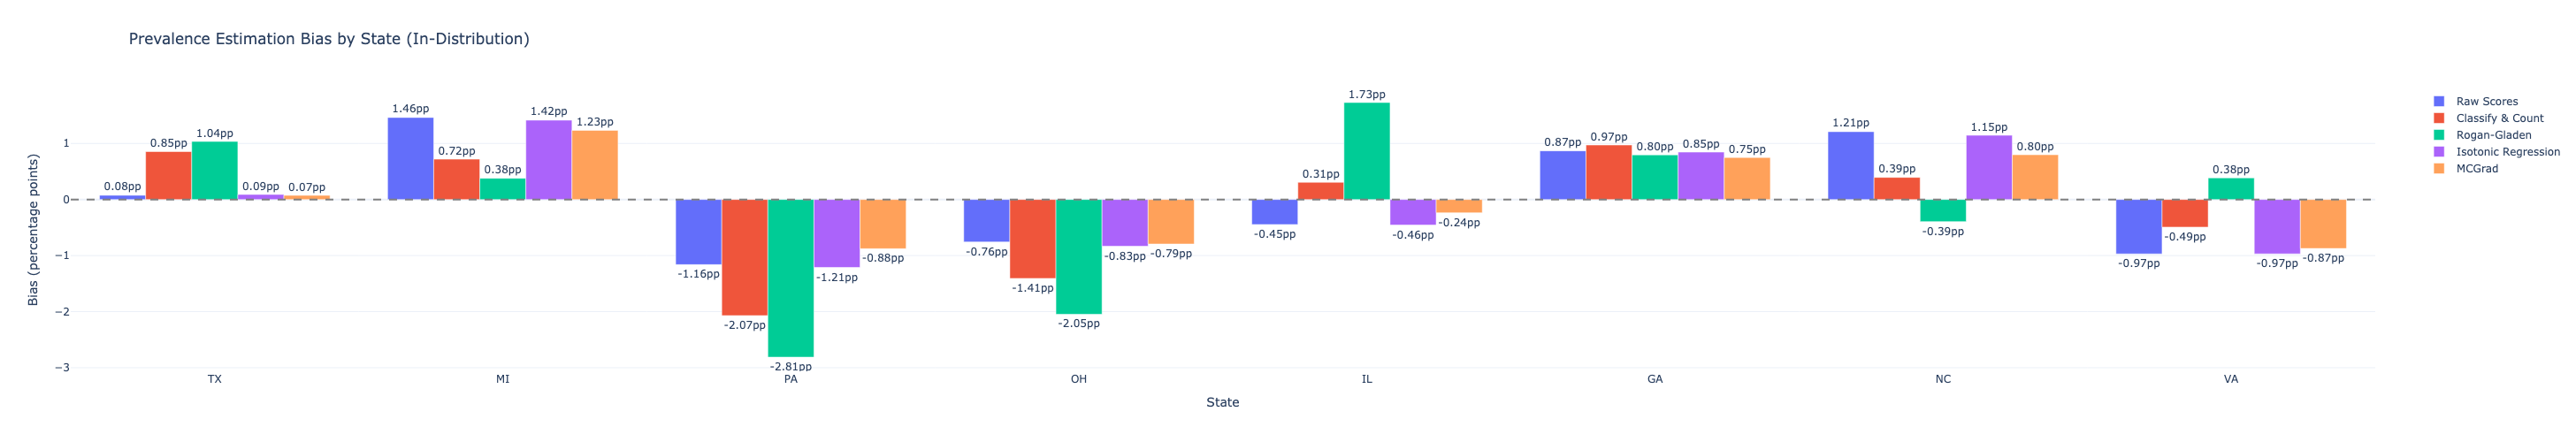

In [32]:
# Visualize bias by state segment
import plotly.graph_objects as go

methods_to_plot = ["Raw Scores", "Classify & Count", "Rogan-Gladen", "Isotonic Regression", "MCGrad"]

fig = go.Figure()

for method in methods_to_plot:
    biases = []
    segments = []
    for segment_name, estimates in segment_results.items():
        true_prev = estimates["True Prevalence"]
        bias = estimates[method] - true_prev
        biases.append(bias * 100)  # Convert to percentage points
        segments.append(segment_name)
    
    fig.add_trace(go.Bar(
        name=method,
        x=segments,
        y=biases,
        text=[f"{b:.2f}pp" for b in biases],
        textposition='outside',
    ))

fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.update_layout(
    title="Prevalence Estimation Bias by State (In-Distribution)",
    xaxis_title="State",
    yaxis_title="Bias (percentage points)",
    barmode='group',
    height=500,
    width=900,
)
fig.show()

## 5. Analysis 3: Out-of-Distribution States

We apply the model (trained and calibrated on TX, MI, PA) to estimate prevalence in held-out states (CA, NY, FL). This simulates applying a quantification model to a previously unseen population.

In [33]:
# Analysis 3: OOD prevalence estimation (aggregate)
ood_estimates = compute_all_prevalence_estimates(
    target_df=ood_df,
    base_col=BASE_MODEL_COL,
    ir_col=IR_COL,
    mcgrad_col=MCGRAD_COL,
    label_col=LABEL_COLUMN,
    cal_tpr=calibration_tpr,
    cal_fpr=calibration_fpr,
    threshold=THRESHOLD,
)

print(f"True prevalence in OOD states ({OOD_STATES}): {ood_estimates['True Prevalence']:.4f}")
print("\nPrevalence estimation results (out-of-distribution):")
compute_bias_table(ood_estimates).round(4)

True prevalence in OOD states (['CA', 'NY', 'FL', 'WA', 'AZ', 'CO']): 0.4489

Prevalence estimation results (out-of-distribution):


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.4613,0.0124,2.7633
Classify & Count,0.4653,0.0164,3.6568
Rogan-Gladen,0.4729,0.0240,5.3489
Isotonic Regression,0.4616,0.0127,2.8306
MCGrad,0.4635,0.0145,3.2377


In [34]:
# Analysis 3b: OOD prevalence estimation by STATE segment
ood_segment_results = {}
for state in OOD_STATES:
    segment_df = ood_df[ood_df["STATE"] == state]
    estimates = compute_all_prevalence_estimates(
        target_df=segment_df,
        base_col=BASE_MODEL_COL,
        ir_col=IR_COL,
        mcgrad_col=MCGRAD_COL,
        label_col=LABEL_COLUMN,
        cal_tpr=calibration_tpr,
        cal_fpr=calibration_fpr,
        threshold=THRESHOLD,
    )
    ood_segment_results[state] = estimates
    print(f"\nOOD {state} (n={len(segment_df)}):")
    print(f"  True prevalence: {estimates['True Prevalence']:.4f}")
    display(compute_bias_table(estimates).round(4))


OOD CA (n=1132427):
  True prevalence: 0.4505


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.4622,0.0117,2.5969
Classify & Count,0.4750,0.0245,5.4405
Rogan-Gladen,0.4891,0.0385,8.5545
Isotonic Regression,0.4633,0.0128,2.8309
MCGrad,0.4712,0.0207,4.6009



OOD NY (n=589656):
  True prevalence: 0.4612


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.4658,0.0047,1.0155
Classify & Count,0.4710,0.0098,2.1359
Rogan-Gladen,0.4824,0.0212,4.6007
Isotonic Regression,0.4663,0.0052,1.1211
MCGrad,0.4711,0.0099,2.1502



OOD FL (n=598632):
  True prevalence: 0.4320


...

,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.4667,0.0125,2.7435
Classify & Count,0.4718,0.0176,3.8737
Rogan-Gladen,0.4837,0.0295,6.4922
Isotonic Regression,0.4664,0.0122,2.6941
MCGrad,0.4648,0.0106,2.3270



OOD AZ (n=207251):
  True prevalence: 0.4140


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.4401,0.0261,6.3115
Classify & Count,0.4299,0.0160,3.8580
Rogan-Gladen,0.4140,0.0001,0.0187
Isotonic Regression,0.4393,0.0253,6.1178
MCGrad,0.4337,0.0198,4.7783



OOD CO (n=166099):
  True prevalence: 0.4921


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.4855,-0.0067,-1.3516
Classify & Count,0.4998,0.0076,1.5525
Rogan-Gladen,0.5302,0.0381,7.7377
Isotonic Regression,0.4851,-0.0070,-1.4251
MCGrad,0.4855,-0.0066,-1.3385


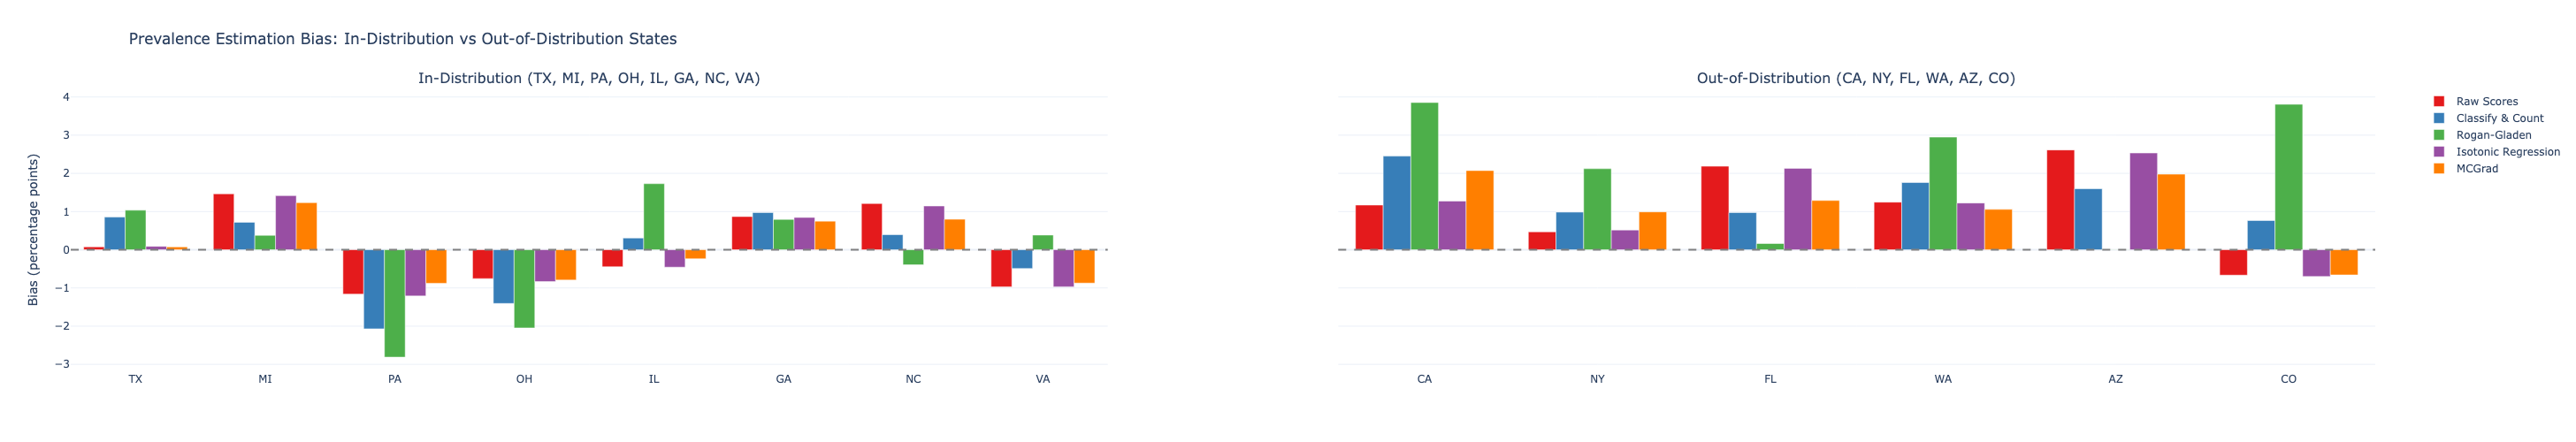

In [35]:
# Combined visualization: In-distribution vs OOD bias by state
from plotly.subplots import make_subplots
from plotly import express as px

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(f"In-Distribution ({', '.join(TRAIN_STATES)})", f"Out-of-Distribution ({', '.join(OOD_STATES)})"),
    shared_yaxes=True,
)

colors = px.colors.qualitative.Set1

for col, (results, title) in enumerate([
    (segment_results, "In-Distribution"),
    (ood_segment_results, "Out-of-Distribution"),
], start=1):
    for i, method in enumerate(methods_to_plot):
        biases = []
        segments = []
        for segment_name, estimates in results.items():
            true_prev = estimates["True Prevalence"]
            bias = estimates[method] - true_prev
            biases.append(bias * 100)
            segments.append(segment_name)
        
        fig.add_trace(
            go.Bar(
                name=method,
                x=segments,
                y=biases,
                marker_color=colors[i],
                showlegend=(col == 1),  # Only show legend for first subplot
            ),
            row=1, col=col,
        )

fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.update_layout(
    title="Prevalence Estimation Bias: In-Distribution vs Out-of-Distribution States",
    yaxis_title="Bias (percentage points)",
    barmode='group',
    height=500,
    width=1200,
)
fig.show()

## 6. Summary

Create a consolidated summary table comparing bias across all scenarios.

In [36]:
# Create summary table of bias across all scenarios
summary_data = []

# Build scenarios list dynamically
scenarios = [("In-Dist (Global)", in_dist_estimates, len(test_df))]
for state in TRAIN_STATES:
    state_df = test_df[test_df["STATE"] == state]
    scenarios.append((f"In-Dist {state}", segment_results[state], len(state_df)))
scenarios.append(("OOD (Global)", ood_estimates, len(ood_df)))
for state in OOD_STATES:
    state_df = ood_df[ood_df["STATE"] == state]
    scenarios.append((f"OOD {state}", ood_segment_results[state], len(state_df)))

for scenario_name, estimates, n_samples in scenarios:
    true_prev = estimates["True Prevalence"]
    row = {"Scenario": scenario_name, "N": n_samples, "True Prevalence": true_prev}
    for method in methods_to_plot:
        bias = estimates[method] - true_prev
        row[f"{method} Bias"] = bias
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data).set_index("Scenario")

# Format for display
display_df = summary_df.copy()
display_df["True Prevalence"] = display_df["True Prevalence"].apply(lambda x: f"{x:.1%}")
for col in display_df.columns:
    if "Bias" in col:
        display_df[col] = display_df[col].apply(lambda x: f"{x*100:+.2f}pp")

display_df

,N,True Prevalence,Raw Scores Bias,Classify & Count Bias,Rogan-Gladen Bias,Isotonic Regression Bias,MCGrad Bias
Scenario,,,,,,,
In-Dist (Global),919815,45.4%,-0.00pp,+0.00pp,+0.00pp,-0.03pp,-0.01pp
In-Dist TX,238752,44.8%,+0.08pp,+0.85pp,+1.04pp,+0.09pp,+0.07pp
In-Dist MI,89106,44.2%,+1.46pp,+0.72pp,+0.38pp,+1.42pp,+1.23pp
In-Dist PA,115131,46.3%,-1.16pp,-2.07pp,-2.81pp,-1.21pp,-0.88pp
In-Dist OH,106607,45.8%,-0.76pp,-1.41pp,-2.05pp,-0.83pp,-0.79pp
In-Dist IL,113781,47.2%,-0.45pp,+0.31pp,+1.73pp,-0.46pp,-0.24pp
In-Dist GA,89616,44.2%,+0.87pp,+0.97pp,+0.80pp,+0.85pp,+0.75pp
In-Dist NC,91005,43.8%,+1.21pp,+0.39pp,-0.39pp,+1.15pp,+0.80pp
In-Dist VA,75817,47.2%,-0.97pp,-0.49pp,+0.38pp,-0.97pp,-0.87pp


In [37]:
# Compute weighted average bias across states (weighted by sample size)
# We compute this separately for in-distribution and OOD states

def compute_weighted_avg_bias(state_results: dict, state_sample_sizes: dict) -> dict:
    """Compute sample-size weighted average absolute bias for each method."""
    total_n = sum(state_sample_sizes.values())
    
    weighted_bias = {method: 0.0 for method in methods_to_plot}
    weighted_abs_bias = {method: 0.0 for method in methods_to_plot}
    
    for state, estimates in state_results.items():
        n = state_sample_sizes[state]
        weight = n / total_n
        true_prev = estimates["True Prevalence"]
        
        for method in methods_to_plot:
            bias = estimates[method] - true_prev
            weighted_bias[method] += weight * bias
            weighted_abs_bias[method] += weight * abs(bias)
    
    return weighted_bias, weighted_abs_bias

# In-distribution states
in_dist_sample_sizes = {state: len(test_df[test_df["STATE"] == state]) for state in TRAIN_STATES}
in_dist_weighted_bias, in_dist_weighted_abs_bias = compute_weighted_avg_bias(segment_results, in_dist_sample_sizes)

# OOD states
ood_sample_sizes = {state: len(ood_df[ood_df["STATE"] == state]) for state in OOD_STATES}
ood_weighted_bias, ood_weighted_abs_bias = compute_weighted_avg_bias(ood_segment_results, ood_sample_sizes)

# Create summary table
weighted_summary = []
for method in methods_to_plot:
    weighted_summary.append({
        "Method": method,
        "In-Dist Weighted Avg Bias (pp)": in_dist_weighted_bias[method] * 100,
        "In-Dist Weighted Avg |Bias| (pp)": in_dist_weighted_abs_bias[method] * 100,
        "OOD Weighted Avg Bias (pp)": ood_weighted_bias[method] * 100,
        "OOD Weighted Avg |Bias| (pp)": ood_weighted_abs_bias[method] * 100,
    })

weighted_summary_df = pd.DataFrame(weighted_summary).set_index("Method")
print("=== Weighted Average Bias Across States ===")
print("(Weighted by state sample size)\n")
weighted_summary_df.round(4)

=== Weighted Average Bias Across States ===
(Weighted by state sample size)



,In-Dist Weighted Avg Bias (pp),In-Dist Weighted Avg |Bias| (pp),OOD Weighted Avg Bias (pp),OOD Weighted Avg |Bias| (pp)
Method,,,,
Raw Scores,-0.0022,0.7337,1.2405,1.3162
Classify & Count,0.0005,0.9257,1.6416,1.6416
Rogan-Gladen,0.0004,1.2564,2.4012,2.4012
Isotonic Regression,-0.0283,0.7406,1.2707,1.3506
MCGrad,-0.0125,0.5932,1.4535,1.5285


## 7. Analysis of Results: Why MCGrad Doesn't Outperform on State-Level Estimation

### Key Observation

The MCE evaluation shows MCGrad **IS working correctly** for multicalibration:
- Base Model MCE: 0.0346 (89σ)  
- Isotonic Regression MCE: 0.0351 (91σ)
- **MCGrad MCE: 0.0022 (6σ)** — a 16x improvement

MCGrad dramatically reduces multicalibration error on the segments it's trained for. So why doesn't this translate to better prevalence estimation by state?

### The Core Issue: Segment Feature Mismatch

The segment features used for MCGrad are:
```
['MAR', 'RELP', 'CIT', 'MIG', 'MIL', 'ANC', 'RAC1P', 'DIS', 'ESP', 'NATIVITY', 'DEAR', 'DEYE', 'DREM', 'SEX']
```

**STATE is not included as a segment feature.**

The theory states that multicalibration guarantees unbiased prevalence estimates for segments **defined by the features the model is multicalibrated on**. MCGrad is calibrated for segments like "Female with disability" or "Male, Hispanic, foreign-born" — but NOT explicitly for "Texas" or "California".

### Why State-Level Bias Persists

1. **MCGrad achieves multicalibration on demographic features**, which helps for comparisons across demographic groups
2. **State captures more than demographics**: Local economy, industry mix, regional culture, policy differences — factors not fully explained by demographic features alone
3. **The base model may already be reasonably calibrated by state** through the demographic features, just not perfectly

### Implications

To properly demonstrate the theory, we need to either:
1. **Include STATE as a segment feature** for in-distribution analysis (Analysis 7a below)
2. **Test prevalence estimation on segments MCGrad IS calibrated for**, like SEX (Analysis 7b below)

### 7a. Analysis with STATE as a Segment Feature

We retrain MCGrad with STATE included as a segment feature. This should eliminate state-level bias for in-distribution states (but cannot help for OOD states, since those weren't seen during training).

In [38]:
# Train MCGrad with STATE as a segment feature
categorical_segment_features_with_state = CATEGORICAL_COLUMNS + BINARY_COLUMNS + ["STATE"]

mcgrad_with_state = methods.MCGrad()
mcgrad_with_state = mcgrad_with_state.fit(
    calibration_df,
    BASE_MODEL_COL,
    LABEL_COLUMN,
    categorical_feature_column_names=categorical_segment_features_with_state,
    numerical_feature_column_names=numerical_segment_features,
)
print("MCGrad with STATE fitted")

# Generate predictions
MCGRAD_STATE_COL = 'mcgrad_with_state_prediction'
test_df[MCGRAD_STATE_COL] = mcgrad_with_state.predict(
    df=test_df,
    prediction_column_name=BASE_MODEL_COL,
    categorical_feature_column_names=categorical_segment_features_with_state,
    numerical_feature_column_names=numerical_segment_features,
)
print("MCGrad with STATE predictions generated")

[WARNING][2026-02-20 16:09:27][methods.py:1464]: Found 6532 (1.01%) predictions with extreme values (boundaries: [4.53979e-05, 0.999955]). These samples will be clipped in the unshrink step. Consider reviewing input prediction quality.
[INFO][2026-02-20 16:09:27][methods.py:550]: Preprocessing input data with 643871 rows; in_fit_phase = True
[INFO][2026-02-20 16:09:28][methods.py:649]: Early stopping activated, max_num_rounds=100 (timeout: 28800s)
[INFO][2026-02-20 16:09:28][methods.py:959]: Determining optimal number of rounds
[INFO][2026-02-20 16:09:28][methods.py:1283]: Found a relatively small effective sample size (643,871.0), choosing k-fold for early stopping. You can override this by explicitly setting `early_stopping_use_crossvalidation` to `False`.
[INFO][2026-02-20 16:09:28][methods.py:929]: Running early stopping using Cross Validation.
[INFO][2026-02-20 16:09:28][methods.py:949]: Using 5 folds for cross-validation.
[INFO][2026-02-20 16:09:28][methods.py:986]: Evaluating ro

MCGrad with STATE fitted
MCGrad with STATE predictions generated


In [39]:
# Compare prevalence estimation bias by state: MCGrad vs MCGrad with STATE
segment_results_with_state = {}

for state in TRAIN_STATES:
    segment_df = test_df[test_df["STATE"] == state]
    true_prev = segment_df[LABEL_COLUMN].mean()
    
    # Original MCGrad estimate
    mcgrad_estimate = segment_df[MCGRAD_COL].mean()
    
    # MCGrad with STATE estimate
    mcgrad_state_estimate = segment_df[MCGRAD_STATE_COL].mean()
    
    # Isotonic for comparison
    isotonic_estimate = segment_df[IR_COL].mean()
    
    segment_results_with_state[state] = {
        "True Prevalence": true_prev,
        "Isotonic Regression": isotonic_estimate,
        "MCGrad (no STATE)": mcgrad_estimate,
        "MCGrad (with STATE)": mcgrad_state_estimate,
    }

# Create comparison table
comparison_data = []
for state, results in segment_results_with_state.items():
    true_prev = results["True Prevalence"]
    comparison_data.append({
        "State": state,
        "True Prev": f"{true_prev:.4f}",
        "Isotonic Bias (pp)": (results["Isotonic Regression"] - true_prev) * 100,
        "MCGrad Bias (pp)": (results["MCGrad (no STATE)"] - true_prev) * 100,
        "MCGrad+STATE Bias (pp)": (results["MCGrad (with STATE)"] - true_prev) * 100,
    })

comparison_df = pd.DataFrame(comparison_data).set_index("State")
print("=== Prevalence Estimation Bias by State (In-Distribution) ===")
print("Comparing Isotonic, MCGrad, and MCGrad with STATE as segment feature\n")
comparison_df.round(4)

=== Prevalence Estimation Bias by State (In-Distribution) ===
Comparing Isotonic, MCGrad, and MCGrad with STATE as segment feature



,True Prev,Isotonic Bias (pp),MCGrad Bias (pp),MCGrad+STATE Bias (pp)
State,,,,
TX,0.4481,0.0898,0.0734,-0.1431
MI,0.4415,1.4154,1.2326,-0.0895
PA,0.4634,-1.2111,-0.8772,0.0458
OH,0.4583,-0.8333,-0.7933,0.0514
IL,0.4723,-0.4560,-0.2356,0.0600
GA,0.4415,0.8456,0.7493,-0.0143
NC,0.4381,1.1451,0.7977,0.0017
VA,0.4720,-0.9688,-0.8728,0.1720


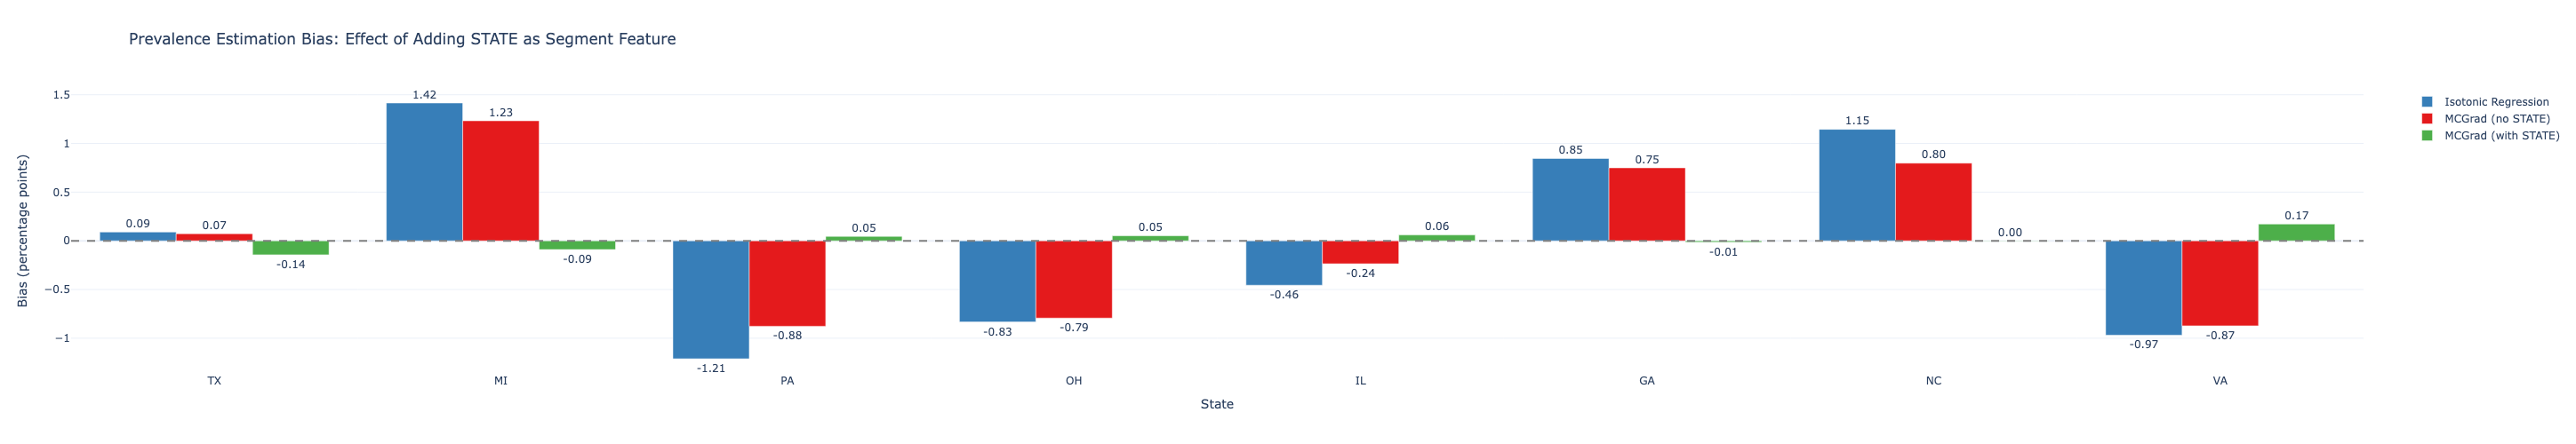


=== Weighted Average |Bias| Across States ===
  Isotonic Regression: 0.7406 pp
  MCGrad (no STATE): 0.5932 pp
  MCGrad (with STATE): 0.0807 pp


In [40]:
# Visualization: Compare bias with and without STATE as segment feature
fig = go.Figure()

methods_7a = ["Isotonic Regression", "MCGrad (no STATE)", "MCGrad (with STATE)"]
colors_7a = ["#377eb8", "#e41a1c", "#4daf4a"]

for method, color in zip(methods_7a, colors_7a):
    col_name = f"{method.replace('(', '').replace(')', '').replace(' ', '_')}_Bias_(pp)" if "MCGrad" in method else "Isotonic_Bias_(pp)"
    biases = []
    for state in TRAIN_STATES:
        true_prev = segment_results_with_state[state]["True Prevalence"]
        estimate = segment_results_with_state[state][method]
        biases.append((estimate - true_prev) * 100)
    
    fig.add_trace(go.Bar(
        name=method,
        x=TRAIN_STATES,
        y=biases,
        marker_color=color,
        text=[f"{b:.2f}" for b in biases],
        textposition='outside',
    ))

fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.update_layout(
    title="Prevalence Estimation Bias: Effect of Adding STATE as Segment Feature",
    xaxis_title="State",
    yaxis_title="Bias (percentage points)",
    barmode='group',
    height=500,
    width=1000,
)
fig.show()

# Compute weighted average absolute bias
total_n = sum(len(test_df[test_df["STATE"] == state]) for state in TRAIN_STATES)
weighted_abs_bias = {method: 0.0 for method in methods_7a}

for state in TRAIN_STATES:
    n = len(test_df[test_df["STATE"] == state])
    weight = n / total_n
    true_prev = segment_results_with_state[state]["True Prevalence"]
    for method in methods_7a:
        bias = segment_results_with_state[state][method] - true_prev
        weighted_abs_bias[method] += weight * abs(bias)

print("\n=== Weighted Average |Bias| Across States ===")
for method in methods_7a:
    print(f"  {method}: {weighted_abs_bias[method]*100:.4f} pp")

### 7b. Analysis by SEX (a segment MCGrad IS calibrated for)

Since MCGrad is multicalibrated with respect to SEX (it's in the segment features), we should see MCGrad outperform Isotonic Regression when estimating prevalence by sex. This directly tests the theory on segments the model is designed for.

In [41]:
# Analysis by SEX - In-Distribution
SEX_LABELS = {1: "Male", 2: "Female"}

sex_results_in_dist = {}
for sex_code, sex_label in SEX_LABELS.items():
    segment_df = test_df[test_df["SEX"] == sex_code]
    estimates = compute_all_prevalence_estimates(
        target_df=segment_df,
        base_col=BASE_MODEL_COL,
        ir_col=IR_COL,
        mcgrad_col=MCGRAD_COL,
        label_col=LABEL_COLUMN,
        cal_tpr=calibration_tpr,
        cal_fpr=calibration_fpr,
        threshold=THRESHOLD,
    )
    sex_results_in_dist[sex_label] = estimates
    print(f"\nIn-Dist {sex_label} (n={len(segment_df)}):")
    print(f"  True prevalence: {estimates['True Prevalence']:.4f}")
    display(compute_bias_table(estimates).round(4))


In-Dist Male (n=449635):
  True prevalence: 0.4836


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.4838,0.0002,0.0502
Classify & Count,0.5068,0.0232,4.7977
Rogan-Gladen,0.5419,0.0583,12.0581
Isotonic Regression,0.4838,0.0002,0.0371
MCGrad,0.4846,0.0010,0.2162



In-Dist Female (n=470180):
  True prevalence: 0.4255


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.4252,-0.0003,-0.0649
Classify & Count,0.4033,-0.0222,-5.2123
Rogan-Gladen,0.3697,-0.0558,-13.1048
Isotonic Regression,0.4247,-0.0007,-0.1706
MCGrad,0.4242,-0.0012,-0.2923


In [42]:
# Analysis by SEX - Out-of-Distribution
sex_results_ood = {}
for sex_code, sex_label in SEX_LABELS.items():
    segment_df = ood_df[ood_df["SEX"] == sex_code]
    estimates = compute_all_prevalence_estimates(
        target_df=segment_df,
        base_col=BASE_MODEL_COL,
        ir_col=IR_COL,
        mcgrad_col=MCGRAD_COL,
        label_col=LABEL_COLUMN,
        cal_tpr=calibration_tpr,
        cal_fpr=calibration_fpr,
        threshold=THRESHOLD,
    )
    sex_results_ood[sex_label] = estimates
    print(f"\nOOD {sex_label} (n={len(segment_df)}):")
    print(f"  True prevalence: {estimates['True Prevalence']:.4f}")
    display(compute_bias_table(estimates).round(4))


OOD Male (n=1429304):
  True prevalence: 0.4792


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.4933,0.0141,2.9510
Classify & Count,0.5212,0.0420,8.7556
Rogan-Gladen,0.5658,0.0866,18.0730
Isotonic Regression,0.4936,0.0144,3.0090
MCGrad,0.4973,0.0181,3.7773



OOD Female (n=1488064):
  True prevalence: 0.4198


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.4306,0.0107,2.5575
Classify & Count,0.4117,-0.0081,-1.9335
Rogan-Gladen,0.3837,-0.0361,-8.6016
Isotonic Regression,0.4309,0.0111,2.6350
MCGrad,0.4309,0.0111,2.6461


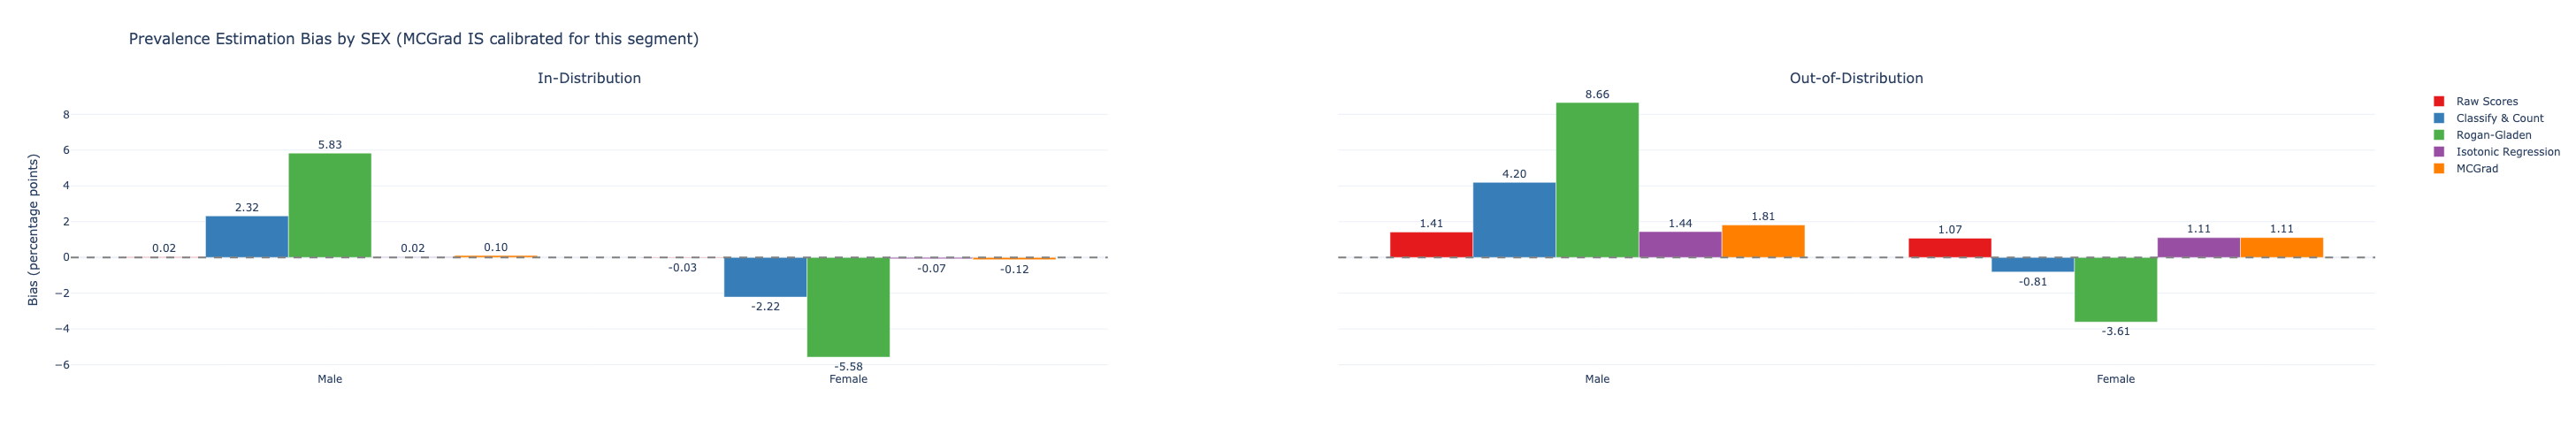

In [43]:
# Visualization: Prevalence estimation bias by SEX
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("In-Distribution", "Out-of-Distribution"),
    shared_yaxes=True,
)

colors = px.colors.qualitative.Set1

for col, (results, title) in enumerate([
    (sex_results_in_dist, "In-Distribution"),
    (sex_results_ood, "Out-of-Distribution"),
], start=1):
    for i, method in enumerate(methods_to_plot):
        biases = []
        segments = []
        for segment_name, estimates in results.items():
            true_prev = estimates["True Prevalence"]
            bias = estimates[method] - true_prev
            biases.append(bias * 100)
            segments.append(segment_name)
        
        fig.add_trace(
            go.Bar(
                name=method,
                x=segments,
                y=biases,
                marker_color=colors[i],
                showlegend=(col == 1),
                text=[f"{b:.2f}" for b in biases],
                textposition='outside',
            ),
            row=1, col=col,
        )

fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.update_layout(
    title="Prevalence Estimation Bias by SEX (MCGrad IS calibrated for this segment)",
    yaxis_title="Bias (percentage points)",
    barmode='group',
    height=500,
    width=1000,
)
fig.show()

In [44]:
# Summary table for SEX analysis
sex_summary_data = []

for sex_label in SEX_LABELS.values():
    # In-distribution
    in_dist_est = sex_results_in_dist[sex_label]
    true_prev_in = in_dist_est["True Prevalence"]
    
    # OOD
    ood_est = sex_results_ood[sex_label]
    true_prev_ood = ood_est["True Prevalence"]
    
    for method in methods_to_plot:
        sex_summary_data.append({
            "Segment": sex_label,
            "Method": method,
            "In-Dist Bias (pp)": (in_dist_est[method] - true_prev_in) * 100,
            "OOD Bias (pp)": (ood_est[method] - true_prev_ood) * 100,
        })

sex_summary_df = pd.DataFrame(sex_summary_data)
sex_pivot = sex_summary_df.pivot(index="Method", columns="Segment", values=["In-Dist Bias (pp)", "OOD Bias (pp)"])
print("=== Summary: Prevalence Estimation Bias by SEX ===\n")
sex_pivot.round(4)

=== Summary: Prevalence Estimation Bias by SEX ===



In-Dist Bias (pp)         OOD Bias (pp)        
Segment                        Female    Male        Female    Male
Method                                                             
Classify & Count              -2.2177  2.3201       -0.8117  4.1957
Isotonic Regression           -0.0726  0.0180        1.1062  1.4419
MCGrad                        -0.1243  0.1046        1.1109  1.8101
Raw Scores                    -0.0276  0.0243        1.0737  1.4141
Rogan-Gladen                  -5.5756  5.8312       -3.6112  8.6607

In [45]:
# Compute weighted average absolute bias for SEX segments
def compute_sex_weighted_bias(results_dict, df, sex_labels):
    """Compute weighted average absolute bias by sex."""
    total_n = len(df)
    weighted_abs_bias = {method: 0.0 for method in methods_to_plot}
    
    for sex_code, sex_label in sex_labels.items():
        segment_df = df[df["SEX"] == sex_code]
        n = len(segment_df)
        weight = n / total_n
        
        estimates = results_dict[sex_label]
        true_prev = estimates["True Prevalence"]
        
        for method in methods_to_plot:
            bias = estimates[method] - true_prev
            weighted_abs_bias[method] += weight * abs(bias)
    
    return weighted_abs_bias

in_dist_sex_bias = compute_sex_weighted_bias(sex_results_in_dist, test_df, SEX_LABELS)
ood_sex_bias = compute_sex_weighted_bias(sex_results_ood, ood_df, SEX_LABELS)

print("=== Weighted Average |Bias| by SEX ===\n")
sex_weighted_summary = []
for method in methods_to_plot:
    sex_weighted_summary.append({
        "Method": method,
        "In-Dist |Bias| (pp)": in_dist_sex_bias[method] * 100,
        "OOD |Bias| (pp)": ood_sex_bias[method] * 100,
    })

pd.DataFrame(sex_weighted_summary).set_index("Method").round(4)

=== Weighted Average |Bias| by SEX ===



,In-Dist |Bias| (pp),OOD |Bias| (pp)
Method,,
Raw Scores,0.0260,1.2405
Classify & Count,2.2677,2.4697
Rogan-Gladen,5.7005,6.0851
Isotonic Regression,0.0459,1.2707
MCGrad,0.1147,1.4535


### 7c. Interpretation

**Analysis 7a (STATE as segment feature):**
- When STATE is included as a segment feature for MCGrad, we expect to see reduced state-level bias for in-distribution states
- This demonstrates that multicalibration works when the relevant segment is included in the calibration

**Analysis 7b (SEX segments):**
- SEX is already included in MCGrad's segment features
- If MCGrad shows lower bias than Isotonic Regression for sex-based prevalence estimation, this confirms the theory
- The key comparison is whether MCGrad maintains its advantage even on OOD data (new states), since the SEX-level calibration should transfer

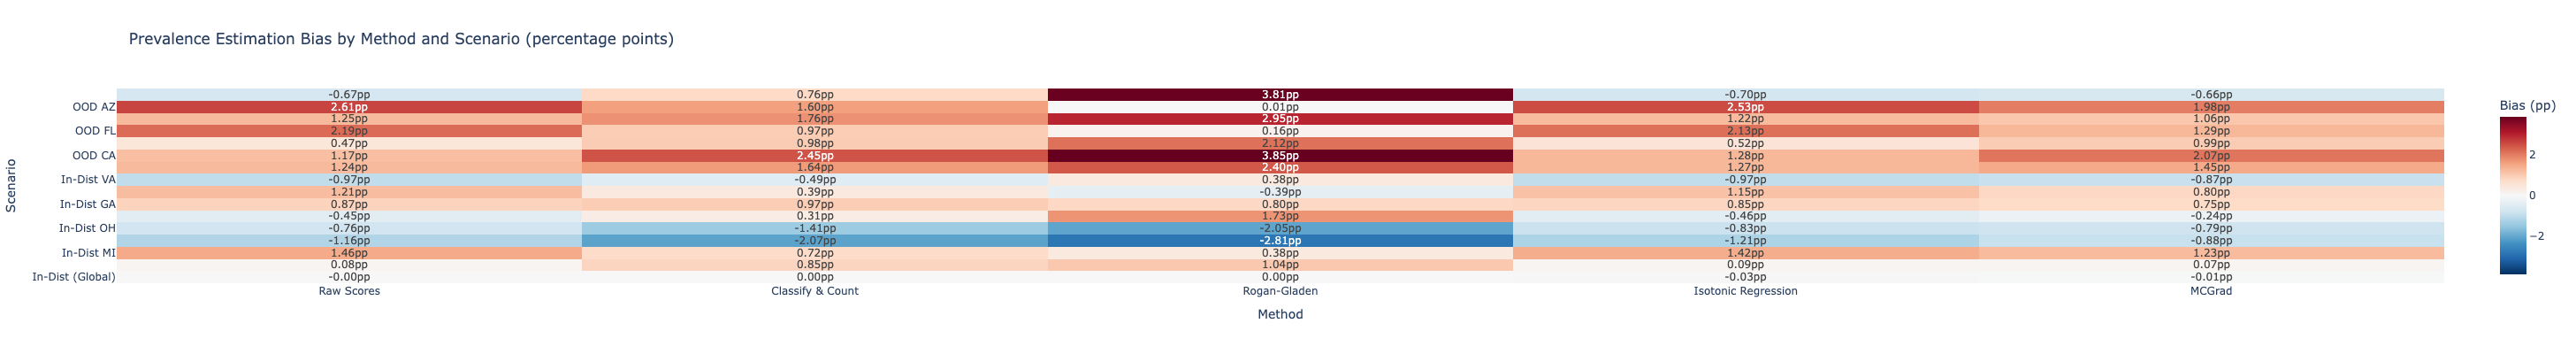

In [46]:
# Heatmap visualization of bias across scenarios
bias_cols = [col for col in summary_df.columns if "Bias" in col]
bias_matrix = summary_df[bias_cols].copy()
bias_matrix.columns = [col.replace(" Bias", "") for col in bias_cols]

# Convert to percentage points for display
bias_matrix_pp = bias_matrix * 100

fig = go.Figure(data=go.Heatmap(
    z=bias_matrix_pp.values,
    x=bias_matrix_pp.columns,
    y=bias_matrix_pp.index,
    colorscale='RdBu_r',
    zmid=0,
    text=[[f"{val:.2f}" for val in row] for row in bias_matrix_pp.values],
    texttemplate="%{text}pp",
    textfont={"size": 12},
    colorbar=dict(title="Bias (pp)"),
))

fig.update_layout(
    title="Prevalence Estimation Bias by Method and Scenario (percentage points)",
    xaxis_title="Method",
    yaxis_title="Scenario",
    height=400,
    width=900,
)
fig.show()

## 8. Analysis: Synthetic Age Distribution Shift

The analyses above show modest differences between methods because **employment rates vary only slightly across states** (a few percentage points). This makes it hard to see the effect of miscalibration on prevalence estimation.

Age tells a very different story: employment rates vary *dramatically* by age — young people (16–24) and the elderly (65+) have far lower employment rates than prime working-age adults (25–54). MCGrad is multicalibrated with respect to AGEP (age), so it should produce unbiased prevalence estimates even when the age distribution shifts substantially.

**Setup:** We take the existing test data (which already has all model predictions) and create synthetic target populations by resampling with different age distributions:
- **Young-skewed**: heavily oversamples ages 16–30
- **Old-skewed**: heavily oversamples ages 60+
- **Original**: baseline (no resampling)

If multicalibration matters, MCGrad should track the true prevalence as we shift the age distribution, while globally-calibrated methods (Isotonic Regression) and threshold-based methods (Classify & Count, Rogan-Gladen) should show increasing bias.

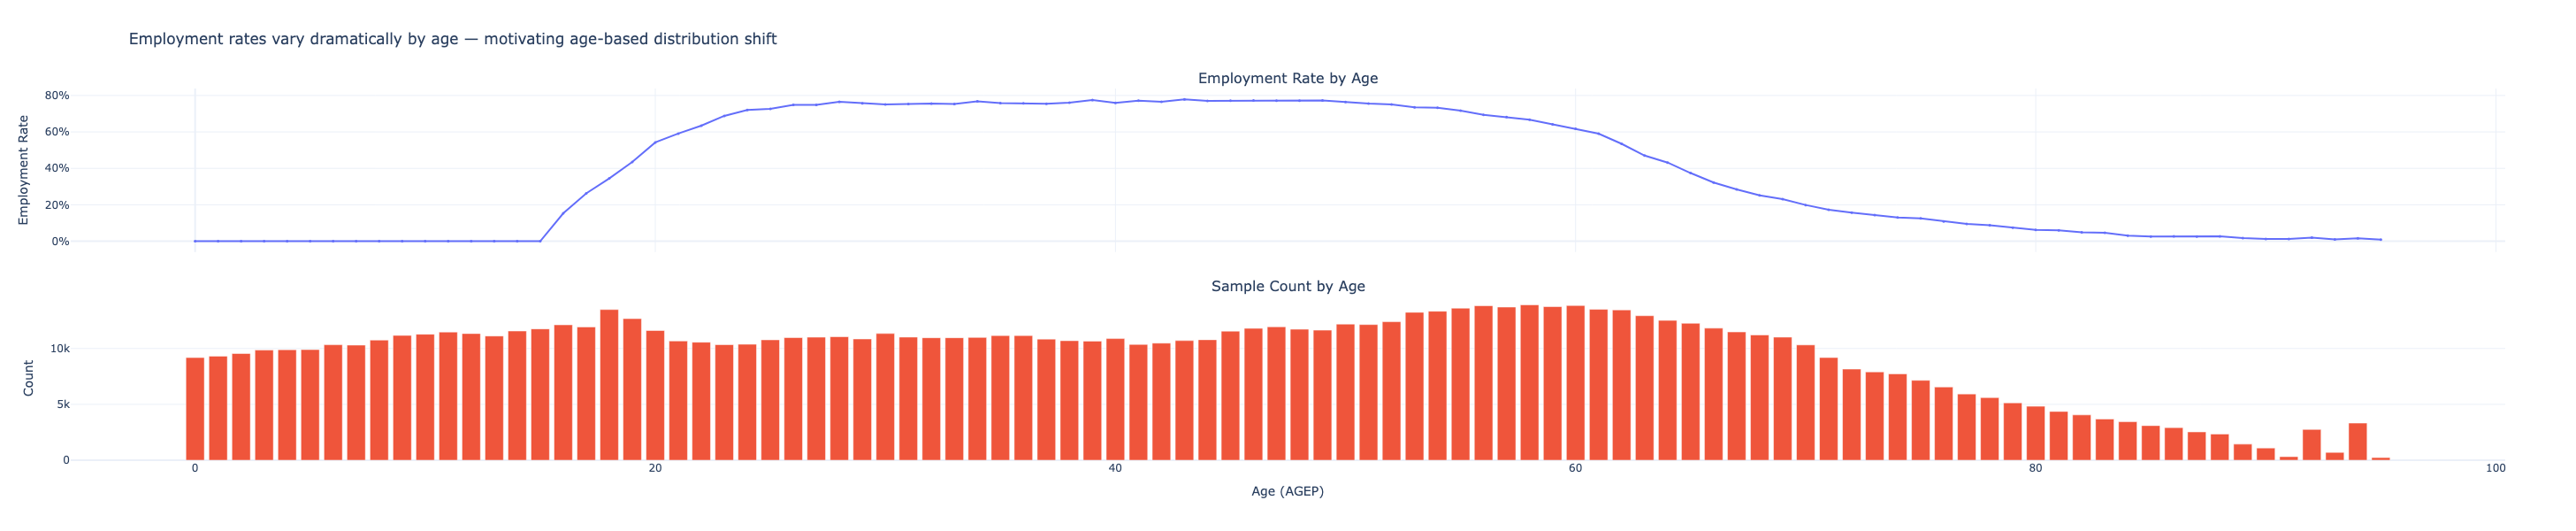

Age 16-24: n=103,771, employment rate=47.3%
Age 25-54: n=339,638, employment rate=75.9%
Age 55-64: n=135,058, employment rate=60.7%
Age 65+: n=165,243, employment rate=17.2%


In [47]:
# Show employment rate by age to motivate the analysis
age_stats = test_df.groupby('AGEP').agg(
    employment_rate=(LABEL_COLUMN, 'mean'),
    count=(LABEL_COLUMN, 'count'),
).reset_index()

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Employment Rate by Age", "Sample Count by Age"),
    shared_xaxes=True,
    vertical_spacing=0.12,
)

fig.add_trace(
    go.Scatter(x=age_stats['AGEP'], y=age_stats['employment_rate'],
               mode='lines+markers', marker=dict(size=3), name='Employment Rate'),
    row=1, col=1,
)
fig.add_trace(
    go.Bar(x=age_stats['AGEP'], y=age_stats['count'], name='Count'),
    row=2, col=1,
)

fig.update_yaxes(title_text="Employment Rate", tickformat=".0%", row=1, col=1)
fig.update_yaxes(title_text="Count", row=2, col=1)
fig.update_xaxes(title_text="Age (AGEP)", row=2, col=1)
fig.update_layout(height=600, width=900, showlegend=False,
                  title="Employment rates vary dramatically by age — motivating age-based distribution shift")
fig.show()

# Print summary stats
for age_range, label in [((16, 24), "16-24"), ((25, 54), "25-54"), ((55, 64), "55-64"), ((65, 90), "65+")]:
    mask = (test_df['AGEP'] >= age_range[0]) & (test_df['AGEP'] <= age_range[1])
    subset = test_df[mask]
    print(f"Age {label}: n={len(subset):,}, employment rate={subset[LABEL_COLUMN].mean():.1%}")

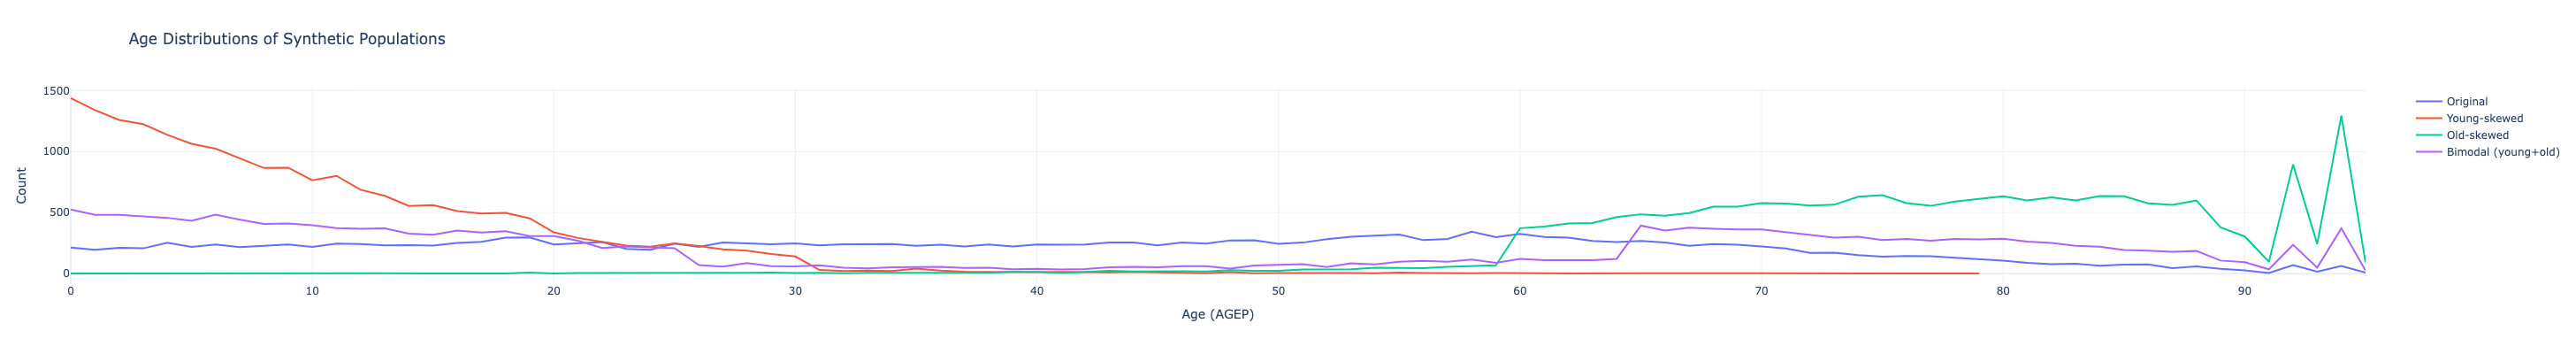

Original: n=20,000, true employment rate = 46.0%, mean age = 41.1
Young-skewed: n=20,000, true employment rate = 12.8%, mean age = 10.2
Old-skewed: n=20,000, true employment rate = 16.8%, mean age = 76.8
Bimodal (young+old): n=20,000, true employment rate = 21.1%, mean age = 41.5


In [48]:
# Create synthetic populations by resampling with different age distributions
# We use the test_df which already has all prediction columns

def resample_with_age_shift(
    df: pd.DataFrame,
    age_col: str = "AGEP",
    shift: str = "original",
    n_samples: int = 20_000,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Resample df with importance weights that shift the age distribution.
    
    shift options:
      - "original": uniform weights (baseline)
      - "young": heavily oversample ages 16-30
      - "old": heavily oversample ages 60+
      - "bimodal": oversample both young and old, undersample middle
    """
    ages = df[age_col].values
    
    if shift == "original":
        weights = np.ones(len(df))
    elif shift == "young":
        # Exponentially favor younger ages
        weights = np.exp(-0.08 * (ages - 16))
        weights = np.where(ages <= 30, weights * 5, weights)
    elif shift == "old":
        # Exponentially favor older ages
        weights = np.exp(0.08 * (ages - 50))
        weights = np.where(ages >= 60, weights * 5, weights)
    elif shift == "bimodal":
        # Favor both tails — young and old
        center = 40
        weights = np.exp(0.04 * np.abs(ages - center))
        weights = np.where((ages <= 25) | (ages >= 65), weights * 3, weights)
    else:
        raise ValueError(f"Unknown shift: {shift}")
    
    weights = weights / weights.sum()
    
    return df.sample(n=n_samples, weights=weights, replace=True, random_state=random_state)


# Define the synthetic scenarios
age_shifts = {
    "Original": "original",
    "Young-skewed": "young",
    "Old-skewed": "old",
    "Bimodal (young+old)": "bimodal",
}

# Generate synthetic populations from the IN-DISTRIBUTION test set
synthetic_populations = {}
for label, shift in age_shifts.items():
    synthetic_populations[label] = resample_with_age_shift(test_df, shift=shift)

# Show the age distributions we created
fig = go.Figure()
for label, syn_df in synthetic_populations.items():
    age_counts = syn_df['AGEP'].value_counts().sort_index()
    fig.add_trace(go.Scatter(
        x=age_counts.index, y=age_counts.values,
        mode='lines', name=label,
    ))

fig.update_layout(
    title="Age Distributions of Synthetic Populations",
    xaxis_title="Age (AGEP)",
    yaxis_title="Count",
    height=400, width=900,
)
fig.show()

# Print true employment rates
for label, syn_df in synthetic_populations.items():
    print(f"{label}: n={len(syn_df):,}, true employment rate = {syn_df[LABEL_COLUMN].mean():.1%}, "
          f"mean age = {syn_df['AGEP'].mean():.1f}")

In [49]:
# Compute prevalence estimates for each synthetic population
synthetic_results = {}

for scenario_label, syn_df in synthetic_populations.items():
    estimates = compute_all_prevalence_estimates(
        target_df=syn_df,
        base_col=BASE_MODEL_COL,
        ir_col=IR_COL,
        mcgrad_col=MCGRAD_COL,
        label_col=LABEL_COLUMN,
        cal_tpr=calibration_tpr,
        cal_fpr=calibration_fpr,
        threshold=THRESHOLD,
    )
    synthetic_results[scenario_label] = estimates
    print(f"\n{scenario_label}:")
    print(f"  True prevalence: {estimates['True Prevalence']:.4f}")
    display(compute_bias_table(estimates).round(4))


Original:
  True prevalence: 0.4595


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.4564,-0.0031,-0.6785
Classify & Count,0.4588,-0.0007,-0.1523
Rogan-Gladen,0.4621,0.0026,0.5574
Isotonic Regression,0.4565,-0.0030,-0.6610
MCGrad,0.4568,-0.0027,-0.5853



Young-skewed:
  True prevalence: 0.1282


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.1475,0.0193,15.0520
Classify & Count,0.1529,0.0247,19.2278
Rogan-Gladen,0.0000,-0.1282,-100.0000
Isotonic Regression,0.1486,0.0204,15.9349
MCGrad,0.1271,-0.0011,-0.8650



Old-skewed:
  True prevalence: 0.1676


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.2399,0.0723,43.0979
Classify & Count,0.1014,-0.0662,-39.5169
Rogan-Gladen,0.0000,-0.1676,-100.0000
Isotonic Regression,0.2341,0.0665,39.6642
MCGrad,0.1699,0.0022,1.3367



Bimodal (young+old):
  True prevalence: 0.2109


,Estimate,Bias,Relative Bias (%)
Method,,,
Raw Scores,0.2566,0.0457,21.6629
Classify & Count,0.1960,-0.0150,-7.1107
Rogan-Gladen,0.0248,-0.1862,-88.2582
Isotonic Regression,0.2543,0.0433,20.5363
MCGrad,0.2121,0.0012,0.5663


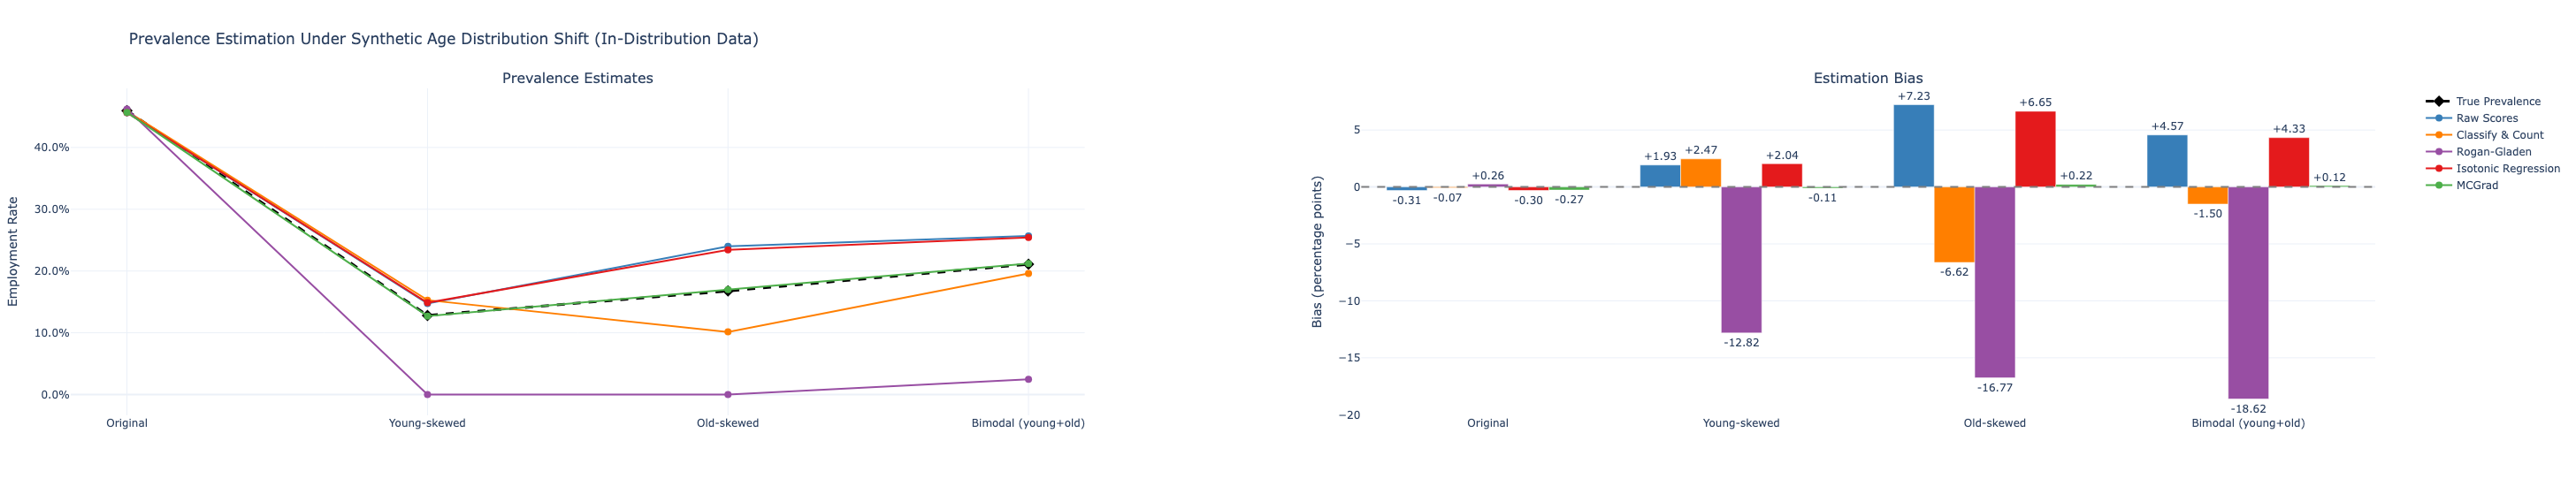

In [50]:
# Visualization: Prevalence estimates vs true prevalence under age distribution shift
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Prevalence Estimates", "Estimation Bias"),
    horizontal_spacing=0.12,
)

scenarios = list(synthetic_results.keys())
colors_map = {
    "Raw Scores": "#377eb8",
    "Classify & Count": "#ff7f00",
    "Rogan-Gladen": "#984ea3",
    "Isotonic Regression": "#e41a1c",
    "MCGrad": "#4daf4a",
}

# Left panel: estimates vs true prevalence
true_prevs = [synthetic_results[s]["True Prevalence"] for s in scenarios]
fig.add_trace(
    go.Scatter(x=scenarios, y=true_prevs, mode='lines+markers',
               name='True Prevalence', line=dict(color='black', width=3, dash='dash'),
               marker=dict(size=10, symbol='diamond')),
    row=1, col=1,
)

for method in methods_to_plot:
    estimates = [synthetic_results[s][method] for s in scenarios]
    fig.add_trace(
        go.Scatter(x=scenarios, y=estimates, mode='lines+markers',
                   name=method, marker=dict(size=8),
                   line=dict(color=colors_map[method])),
        row=1, col=1,
    )

# Right panel: bias (percentage points)
for method in methods_to_plot:
    biases = [(synthetic_results[s][method] - synthetic_results[s]["True Prevalence"]) * 100
              for s in scenarios]
    fig.add_trace(
        go.Bar(x=scenarios, y=biases, name=method, showlegend=False,
               marker_color=colors_map[method],
               text=[f"{b:+.2f}" for b in biases], textposition='outside'),
        row=1, col=2,
    )

fig.add_hline(y=0, line_dash="dash", line_color="gray", row=1, col=2)

fig.update_yaxes(title_text="Employment Rate", tickformat=".1%", row=1, col=1)
fig.update_yaxes(title_text="Bias (percentage points)", row=1, col=2)
fig.update_layout(
    title="Prevalence Estimation Under Synthetic Age Distribution Shift (In-Distribution Data)",
    height=550, width=1200,
    barmode='group',
)
fig.show()

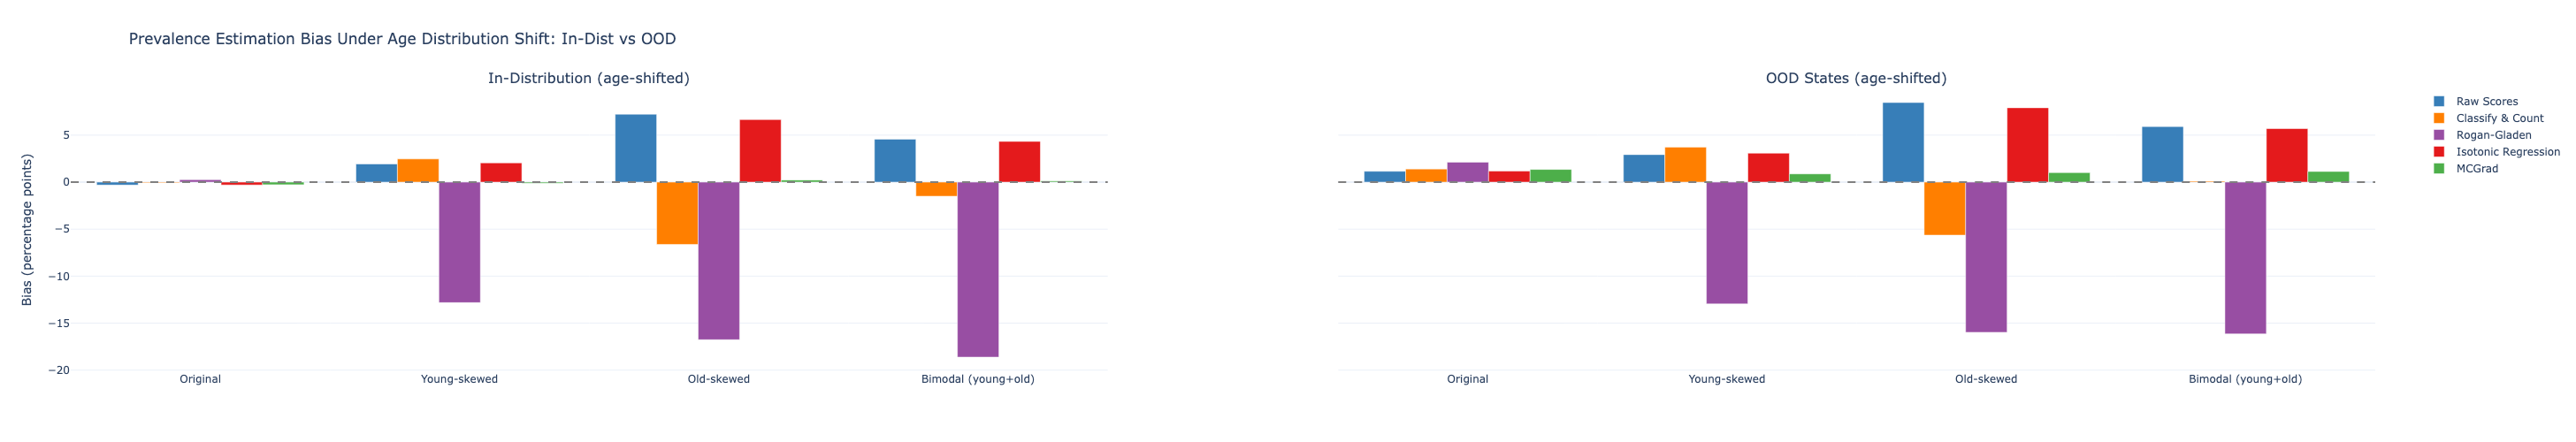

In [51]:
# Repeat on OOD data: synthetic age shifts applied to held-out states
# This combines distribution shift on TWO axes: geography (OOD states) AND age

synthetic_populations_ood = {}
for label, shift in age_shifts.items():
    synthetic_populations_ood[label] = resample_with_age_shift(ood_df, shift=shift)

synthetic_results_ood = {}
for scenario_label, syn_df in synthetic_populations_ood.items():
    estimates = compute_all_prevalence_estimates(
        target_df=syn_df,
        base_col=BASE_MODEL_COL,
        ir_col=IR_COL,
        mcgrad_col=MCGRAD_COL,
        label_col=LABEL_COLUMN,
        cal_tpr=calibration_tpr,
        cal_fpr=calibration_fpr,
        threshold=THRESHOLD,
    )
    synthetic_results_ood[scenario_label] = estimates

# Side-by-side: In-dist vs OOD under age shift
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("In-Distribution (age-shifted)", "OOD States (age-shifted)"),
    shared_yaxes=True,
)

for col, results in enumerate([synthetic_results, synthetic_results_ood], start=1):
    for i, method in enumerate(methods_to_plot):
        biases = [(results[s][method] - results[s]["True Prevalence"]) * 100
                  for s in scenarios]
        fig.add_trace(
            go.Bar(x=scenarios, y=biases, name=method,
                   marker_color=colors_map[method],
                   showlegend=(col == 1)),
            row=1, col=col,
        )

fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.update_yaxes(title_text="Bias (percentage points)", row=1, col=1)
fig.update_layout(
    title="Prevalence Estimation Bias Under Age Distribution Shift: In-Dist vs OOD",
    height=500, width=1200,
    barmode='group',
)
fig.show()

In [52]:
# Summary table: bias across all age-shift scenarios
age_shift_summary = []

for setting, results in [("In-Dist", synthetic_results), ("OOD", synthetic_results_ood)]:
    for scenario, estimates in results.items():
        true_prev = estimates["True Prevalence"]
        row = {
            "Setting": setting,
            "Age Distribution": scenario,
            "True Prevalence": f"{true_prev:.1%}",
        }
        for method in methods_to_plot:
            bias_pp = (estimates[method] - true_prev) * 100
            row[f"{method}"] = f"{bias_pp:+.2f}pp"
        age_shift_summary.append(row)

age_shift_summary_df = pd.DataFrame(age_shift_summary).set_index(["Setting", "Age Distribution"])
print("=== Prevalence Estimation Bias Under Age Distribution Shift ===\n")
age_shift_summary_df

=== Prevalence Estimation Bias Under Age Distribution Shift ===



True Prevalence Raw Scores Classify & Count  \
Setting Age Distribution                                                  
In-Dist Original                      46.0%    -0.31pp          -0.07pp   
        Young-skewed                  12.8%    +1.93pp          +2.47pp   
        Old-skewed                    16.8%    +7.23pp          -6.62pp   
        Bimodal (young+old)           21.1%    +4.57pp          -1.50pp   
OOD     Original                      45.1%    +1.15pp          +1.40pp   
        Young-skewed                  13.0%    +2.93pp          +3.73pp   
        Old-skewed                    16.0%    +8.47pp          -5.64pp   
        Bimodal (young+old)           20.8%    +5.91pp          +0.09pp   

                            Rogan-Gladen Isotonic Regression   MCGrad  
Setting Age Distribution                                               
In-Dist Original                 +0.26pp             -0.30pp  -0.27pp  
        Young-skewed            -12.82pp             +2.04pp  -0.11pp  
        Old-skewed              -16.77pp             +6.65pp  +0.22pp  
        Bimodal (young+old)     -18.62pp             +4.33pp  +0.12pp  
OOD     Original                 +2.12pp             +1.17pp  +1.35pp  
        Young-skewed            -12.96pp             +3.08pp  +0.88pp  
        Old-skewed              -15.97pp             +7.91pp  +1.01pp  
        Bimodal (young+old)     -16.14pp             +5.69pp  +1.13pp

### 8.1 Interpretation

**Why this analysis is more revealing than the state-based analysis:**
- Employment rates differ by only ~2–3pp across states, so even a miscalibrated model can get close by luck
- Employment rates differ by **30–40pp** between age groups (e.g., ~40% for ages 16–20 vs ~80% for ages 35–50), so shifting the age distribution creates large changes in true prevalence that expose calibration failures

**Expected pattern:**
- **Globally calibrated methods** (Isotonic Regression, Raw Scores) learn an overall mapping from scores to probabilities. When the age distribution shifts, the mix of subgroups changes, and the global calibration curve no longer matches — producing biased prevalence estimates.
- **Threshold-based methods** (Classify & Count, Rogan-Gladen) rely on TPR/FPR estimated from the calibration set. These error rates change when the age mix shifts (younger/older populations may be harder or easier to classify), causing bias.
- **MCGrad** is multicalibrated with respect to age (AGEP is a numerical segment feature). This means the predicted probabilities are correct *conditional on age*, so even when the age distribution shifts, the average of the calibrated scores still equals the true prevalence.